In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression,mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,root_mean_squared_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, ParameterGrid
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
import seaborn as sns
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.model_selection import cross_validate
from matplotlib import pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from utility import FeatureCreator, GroupwisePLSTransformer, ColumnSelector, detect_outliers
from tqdm.notebook import tqdm
from joblib import parallel_backend
import re
from copy import deepcopy
import pickle
from tqdm.notebook import tqdm  # plain text tqdm
import contextlib
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import cma
from sklearn.model_selection import TimeSeriesSplit, check_cv
from sklearn.cross_decomposition import PLSRegression
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import plotly.graph_objects as go
import plotly.express as px


sns.set(rc={"figure.figsize":(12, 4)})
sns.set_style('whitegrid')
sns.set_context('notebook')

In [3]:
control_vars = {
    "Steam_flow_to_AfterDryers" : [
        "retention",
        #"Water_flow_Afterdryer",
        "Current_basis_weight",
        "Water_flow_Afterdryer_input",
        "Water_flow_Afterdryer_output",
        "Web_tension_AD6",
        "Moisture_out_of_PreDryer",
        'Cylinder_36_steam_pressure',
        'Cylinder_36_differential_pressure',
        'Cylinder_37_steam_pressure',
        'Cylinder_38_differential_pressure',
        'Cylinder_37_differential_pressure',
        'Cylinder_38_steam_pressure',
        'Cylinder_39_steam_pressure',
        'Cylinder_36-39_steam_pressure',
        'Cylinder_39_differential_pressure',
        'Cylinder_40-53_differential_pressure',
        'Cylinder_40-53_steam_pressure',
        'DG4_Temperature_Inlet_Air',
        'DG5_Temperature_Inlet_Air',
        'DG4_Moisture_content_Outlet_Air',
        'DG5_Moisture_content_Outlet_Air',
        "AD7_fabric_tension_bottom",
        "AD6_fabric_tension",
        "flow_diluted_starch",
        #"Starch_uptake__g/m2_",

    ],

    "Steam_flow_to_PreDryers" : [
        "retention",
        "dewatering",
        "Water_flow_Predryer",
        "Current_basis_weight", # Scanner
        # 'Speed', 
        # 'Speed_PD1', 
        # 'Speed_press_section', 
        # 'Speed_PD2', 
        # 'Speed_PD3', 
        # 'Speed_PD4_top', 
        # 'Speed_PD4_bottom', 
        # 'Speed_PD5_bottom',
        "Draw_PS-PD1", #Pre-dryer
        "Draw_PD2-PD3", #Pre-dryer
        "Draw_PD4-PD5", #Pre-dryer 
        "Draw_PD3-PD4", #Pre-dryer 
        "Draw_PD1-PD2", #Pre-dryer
        "Moisture_out_of_PreDryer", #Pre-dryer
        "Draw_WS-PS", # Press Section
        "PickUp_Tension", # Press Section
        "Vacuum_presszone_of_suction-press_roll", # Press Section
        "Vacuum_uhle-box_Pick-Up", # Press Section
        "Vacuum_uhle-box_bottom_felt", # Press Section
        "Linepressure_1st_press_FS__bar_", # Press Section
        "Linepressure_2nd_press_FS__bar_", # Press Section
        "Linepressure_1st_press_DS__bar_", # Press Section
        "Linepressure_2nd_press_DS__bar_", # Press Section 
        "Linepressure_shoe_press__bar_", # Press Section 
        "Vacuum_Zone_1_PickUp",# Press Section
        
        'Cylinder_1_differential_pressure',
        'Cylinder_1_steam_pressure',
        'Cylinder_2_steam_pressure',
        'Cylinder_3_differential_pressure',
        'Cylinder_2_differential_pressure',
        'Cylinder_3_steam_pressure',
        'Cylinder_4_differential_pressure',
        'Cylinder_5_steam_pressure',
        'Cylinder_4_steam_pressure',
        'Cylinder_5_differential_pressure',
        'Cylinder_1-5_steam_pressure',
        'Cylinder_1-5_fresh_steam',
        'Cylinder_6-15_differential_pressure',
        'Cylinder_6-15_steam_pressure',
        'Cylinder_1-5_steam_temperature',
        'Cylinder_14_differential_pressure',
        'Cylinder_16-24_steam_pressure',
        'Cylinder_25-35_steam_pressure',
        'Cylinder_6-35_differential_pressure',
        
        "ambient_temp_C",
        
        
        #"Dewatering_top_wire_suction_box_zone_1", # Forming Wire (BAD)
        #"Dewatering_Jet_channel", # Forming Wire (BAD)
        "Dewatering_top_wire_suction_box_zone_2", # Forming Wire
        "Vacuum_suction_box_9", 
        "Vacuum_wet_suction_box", # Forming Wire
        "Vacuum_sheet_seperator_box", # Forming Wire
        "Vacuum_suction_box_10", # Forming Wire
        "Vacuum_suction_box_11", # Forming Wire
        "Vacuum_wire_suction_box_1", # Forming Wire
        "Vacuum_wire_suction_box_2", # Forming Wire
        #"Consistency_white_water", # Forming Wire
        "White_water_temperature", # Forming Wire
        "Conductivity_white_water_B46", # Forming Wire
        "Top_wire_tenstion", # Forming Wire
        "pH_measurement_white_water_B41", # Forming Wire
        
        "Jet/wire_ratio", # Headbox
        "Lip_settings", # Headbox
        
        "Retention_Aid_mass_flow__g/T_", # Approach Flow
        "Bentonite_1_mass_flow__g/T_", # Approach Flow
        "Bentonite_2_mass_flow__g/T_", # Approach Flow
        "Thick_Stock_Consistency__%_", # Approach Flow
        
        #"Headbox_consistency",
        
        "pH-Messung_Verdünnungswasser__2..12_pH_",
        "Dissolved_gas_after_stock_deculator_measurement_1",
        "Dissolved_gas_before_dilution_water_deculator",        
        
        "Top_Felt_Tension",
        "Bottom_wire_tension",
        "Bottom_Felt_Tension",
        
        "PD4_fabric_tension",
        "PD1_Fabric_tension",
        "PD2_Fabric_tension",
        "PD5_fabric_tension_top",
        "PD5_fabric_tension_bottom",
       
        "Act_Deaerator_mass_flow__g/T_",
        
        "Natriumhydroxide_mass_flow__g/T_",
        
        "Air_pressure_of_rod_clamping_hose_Top_Roll",
        "Free_gas_before_dilution_water_deculator_measurement_2",
        "Free_gas_before_dilution_water_deculator_measurement_1~^0",
        "Free_gas_after_stock_deculator~^0",
        "Storage_tank_temperature",
        
        "Vacuum_top_wire_suction_box_zone_2",
        "Vacuum_formning_roll",
        "Vacuum_top_wire_suction_box_zone_1",
        "Airturn_pillow_pressure",
        "Dewatering_Suction_Press_Roll",
        "Dewatering_First_Press_Roll",
        
        "Current_reel_width",
        "Steam_temperature_for_PM",
        "Steam_pressure_for_PM",
                
        'Dewatering_Shoe_press',        
        'Total_Dewatering_Press',        
        'Uhle_box_1_flow___l/min_',
        
        "Stock_deculator_temperature",
        'Stock_deculator_pressure',
        
        'Fixative_2_mass_flow__g/T_',

        'Inlet_Air_2_Temperature',
        'Inlet_Air_1_Temperature',
    
        'DG1_temperature_Inlet_Air',
        'DG2_temperature_Inlet_Air',
        'DG3_temperature_Inlet_Air',
        
        'DG1_Moisture_content_Outlet_Air',
        'DG2_Moisture_content_Outlet_Air',
        'DG3_Moisture_content_Outlet_Air',
       
        'DG1_Ventilator_Revolution_Output',
        'DG2_Ventilator_Revolution_Output',
        'DG3_Ventilator_Revolution_Output',
        
        #"ambient_temp_C",
        
       
    ],
    "Electricity__kWh/T_": [
        "retention",
        "dewatering",
        "Current_basis_weight", # Scanner
        'AD6_speed','AD7_speed_bottom','Speed','Forming_Wire_Speed','Speed_Size_Press','Speed_PD4_bottom', 'Speed_PD5_bottom','AD7_speed_top','Speed_PD1','Speed_PD3','Speed_PD2','Speed_PD4_top','Speed_PD5_top','Speed_press_section',
        'Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3',
        "Current_reel_moisture_average(reel)", # Scanner
        
        #"Actual_moisture", # (Moisture before SpeedSizer) Scanner
        #"BSW_2_sigma", # Scanner
        #"Mois_2_sigma", # Scanner
        
        #"Sizing_Agent__g/T_", # Size Press
        #"Starch_uptake__g/m2_", # Size Press
        #"ratio_starch", # Size Press
        #"flow_diluted_starch",
        #'Flow_starch_main_line_to_working_tank', # Size Press
        #"Draw_PD5-SS",  # Size Press
        #"Defoamer_mass_flow__g/T_", # Size Press
        #"Dry_Strength_Agent_mass_flow__kg/T_", # Size Press
        "SpeedSizer_Linepressure_DS", # Size Press
        "SpeedSizer_Linepressure_FS", # Size Press
        "Consistency_starch_main_line", # Size Press
        
        "Moisture_out_of_PreDryer", #Pre-dryer
    
        "PickUp_Tension", # Press Section
        "Vacuum_presszone_of_suction-press_roll", # Press Section
        "Vacuum_uhle-box_Pick-Up", # Press Section
        "Vacuum_uhle-box_bottom_felt", # Press Section
        "Linepressure_1st_press_FS__bar_", # Press Section
        "Linepressure_2nd_press_FS__bar_", # Press Section
        "Linepressure_1st_press_DS__bar_", # Press Section
        "Linepressure_2nd_press_DS__bar_", # Press Section
        "Linepressure_shoe_press__bar_", # Press Section
        
        #"Dewatering_top_wire_suction_box_zone_1", # Forming Wire (BAD)
        #"Dewatering_Jet_channel", # Forming Wire (BAD)
        "Dewatering_top_wire_suction_box_zone_2", # Forming Wire
        "Vacuum_suction_box_9", "Vacuum_wet_suction_box", # Forming Wire
        "Vacuum_sheet_seperator_box", # Forming Wire
        "Vacuum_suction_box_10", # Forming Wire
        "Vacuum_suction_box_11", # Forming Wire
        "Vacuum_wire_suction_box_1", # Forming Wire
        "Vacuum_wire_suction_box_2", # Forming Wire
        #"Consistency_white_water", # Forming Wire
        "White_water_temperature", # Forming Wire
        "Conductivity_white_water_B46", # Forming Wire
        "Top_wire_tenstion", # Forming Wire
        "pH_measurement_white_water_B41", # Forming Wire
        
        "Jet/wire_ratio", # Headbox
        "Lip_settings", # Headbox
        
        #"Retention_Aid_mass_flow__g/T_", # Approach Flow
        #"Bentonite_1_mass_flow__g/T_", # Approach Flow
        #."Bentonite_2_mass_flow__g/T_", # Approach Flow
        "Thick_Stock_Consistency__%_", # Approach Flow
 
],
    "Starch_uptake__g/m2_":[
    "Rod_pressure_Top_Roll",
    "Rod_Pressure_Bottom_Roll",
    "Speed_Size_Press",
    "Current_basis_weight",
    "concentration_starch_working_tank_1",   
    "Temperature_starch_working_tank_1",   
    "concentration_starch_working_tank_2",   
    "Temperature_starch_working_tank_2",   
    'Current_reel_moisture_average(SpeedSizer)',
    'Moisture_after_SpeedSizer',
    "retention",
    "Retention_Aid_mass_flow__g/T_",
    "Bentonite_1_mass_flow__g/T_", 
    "Bentonite_2_mass_flow__g/T_", 
    "Current_reel_moisture_average(reel)",
    "Moisture_out_of_PreDryer",
    "Jet/wire_ratio", 
    "Lip_settings", 
    "White_water_temperature", # Forming Wire
    "Conductivity_white_water_B46", # Forming Wire
    "Top_wire_tenstion", # Forming Wire
    "pH_measurement_white_water_B41", # Forming Wire
    "SpeedSizer_Linepressure_DS", # Size Press
    "SpeedSizer_Linepressure_FS", # Size Press
 
],
'Starch_uptake_by_paper_Bottom_Roll__g/m2_' :[
    "grammage",
    "inv_Rod_Pressure_Bottom_Roll",
    #"Rod_Pressure_Bottom_Roll",
    "Speed_Size_Press",
    #"Current_basis_weight",
    "concentration_starch_working_tank_1",   
    "Temperature_starch_working_tank_1",   
    'Current_reel_moisture_average(SpeedSizer)',
    'Moisture_after_SpeedSizer',
    "retention",
    "Retention_Aid_mass_flow__g/T_",
    # "Bentonite_1_mass_flow__g/T_", 
    # "Bentonite_2_mass_flow__g/T_", 
    # "Current_reel_moisture_average(reel)",
    "Moisture_out_of_PreDryer",
    "Jet/wire_ratio", 
    "Lip_settings", 
    "White_water_temperature", # Forming Wire
    "Conductivity_white_water_B46", # Forming Wire
    "Top_wire_tenstion", # Forming Wire
    "pH_measurement_white_water_B41", # Forming Wire
    "SpeedSizer_Linepressure_DS", # Size Press
    "SpeedSizer_Linepressure_FS", # Size Press
],
'Starch_uptake_by_paper_Top_Roll__g/m2_':[
    "grammage",
    "inv_Rod_pressure_Top_Roll",
    #"Rod_pressure_Top_Roll",
    #"square_Rod_pressure_Top_Roll",
    "Speed_Size_Press",
    #"Current_basis_weight",
    "concentration_starch_working_tank_2",   
    "Temperature_starch_working_tank_2",   
    'Current_reel_moisture_average(SpeedSizer)',
    'Moisture_after_SpeedSizer',
    "retention",
    "Retention_Aid_mass_flow__g/T_",
    "Bentonite_1_mass_flow__g/T_", 
    "Bentonite_2_mass_flow__g/T_", 
    "Current_reel_moisture_average(reel)",
    "Moisture_out_of_PreDryer",
    "Jet/wire_ratio", 
    "Lip_settings", 
    "White_water_temperature", # Forming Wire
    "Conductivity_white_water_B46", # Forming Wire
    "Top_wire_tenstion", # Forming Wire
    "pH_measurement_white_water_B41", # Forming Wire
    "SpeedSizer_Linepressure_DS", # Size Press
    "SpeedSizer_Linepressure_FS", # Size Press
],
'MBS_SCT_CD':[
    "retention",
    "grammage",
    "Speed",
    'Current_reel_moisture_average(SpeedSizer)',
    "Current_reel_moisture_average(reel)",
    'SpeedSizer_Linepressure_DS',
    'SpeedSizer_Linepressure_FS',
    "Starch_uptake__g/m2_",   
    'Consistency_starch_main_line',
    'Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3',
    "Linepressure_1st_press_FS__bar_", # Press Section
    "Linepressure_2nd_press_FS__bar_", # Press Section
    "Linepressure_1st_press_DS__bar_", # Press Section
    "Linepressure_2nd_press_DS__bar_", # Press Section 
    "Linepressure_shoe_press__bar_", # Press Section 
    "pH_measurement_white_water_B41", # Forming Wire
    'Headbox_consistency',    
    "Lip_settings",
    "Jet/wire_ratio",
    "Retention_Aid_mass_flow__g/T_", # Approach Flow
    "Bentonite_1_mass_flow__g/T_", # Approach Flow
    "Bentonite_2_mass_flow__g/T_", # Approach Flow   
    "fibre_short/long"
],
"recommended": [
    "Speed",
    'Current_reel_moisture_average(SpeedSizer)',
    "Current_reel_moisture_average(reel)",
    'Starch_mass_flow__kg/T_',
    'Dry_Strength_Agent_mass_flow__kg/T_',
    'SpeedSizer_Linepressure_DS',
     'SpeedSizer_Linepressure_FS',
    "Starch_uptake_by_paper_Top_Roll__g/m2_",
     "Starch_uptake_by_paper_Bottom_Roll__g/m2_",
    'Starch_consumption_Bottom___m³/h_',
     'Starch_consumption_Top__m³/h_',
    'Consistency_starch_main_line',
    "Draw_WS-PS",
    "Linepressure_1st_press_FS__bar_", # Press Section
    "Linepressure_2nd_press_FS__bar_", # Press Section
    "Linepressure_1st_press_DS__bar_", # Press Section
    "Linepressure_2nd_press_DS__bar_", # Press Section 
    "Linepressure_shoe_press__bar_", # Press Section 
     "pH_measurement_white_water_B41", # Forming Wire
    'Headbox_consistency',
     'Headbox_total_flow',
     "Lip_settings",
    "Jet/wire_ratio",
    "Retention_Aid_mass_flow__g/T_", # Approach Flow
    "Bentonite_1_mass_flow__g/T_", # Approach Flow
    "Bentonite_2_mass_flow__g/T_", # Approach Flow
     "Thick_Stock_Consistency__%_", # Approach Flow
     'Thick_Stock_Flow__l/min_',
    'Short_fibre_flow',
     'Long_fibre_flow',
     'Dry_broke_flow',
     'Wet_broke_flow',    
]
}

In [ ]:
def outlier(y, option="IQR"):
    import numpy as np
    
    def hampel(series, window=24, n=3.0):
        x = series.copy()
        med = x.rolling(window, center=True).median()
        mad = (np.abs(x - med)).rolling(window, center=True).median()
        k = 1.4826  # ~1/MAD-to-sigma
        diff = np.abs(x - med) / (k*mad)
        return diff > n

    if option=="IQR":
        q1, q3 = y.quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
        mask = (y < low) | (y > high)
        return mask
    elif option=="MAD":
        med = y.median()
        mad = (np.abs(y - med)).median()
        modz = 0.6745 * (y - med) / mad
        mask = modz.abs() > 3.5
        return mask
    elif option=="Hampel":
        return hampel(y, window=24, n=3)
    elif option=="PctClip":
        low, high = y.quantile([0.01, 0.99])
        y_clipped = y.clip(lower=low, upper=high)   # cap
        # or drop
        mask = (y < low) | (y > high)
        return mask
    elif option=="StrPctClip":
        low, high = y.quantile([0.001, 0.999])
        y_clipped = y.clip(lower=low, upper=high)   # cap
        # or drop
        mask = (y < low) | (y > high)
        return mask
    
def transform(turnup, ycol):
    import pandas as pd
    import numpy as np
    
    turnup['MBS_Current_reel_ID']=turnup['MBS_Current_reel_ID'].astype(int)
    turnup['AB_Grade_ID']=turnup['AB_Grade_ID'].astype(int)
    turnup['Wedge_Time']=pd.to_datetime(turnup['Wedge_Time'])
    
    turnup["grammage"]=turnup["AB_Grade_ID"].apply(lambda s: s-int(s/1000)*1000 )
    turnup["paper_type"]=turnup["AB_Grade_ID"].apply(lambda s: int(s/1000)).astype("string")
    
    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e in v.lower() for e in ["€","g/m2","g/t","mbs_","t/t","level","consistency","temperature","l/min","fibre_fraction","moisture","dry_average",'pressure_reel_holders','_differential_pressure']):
            turnup.loc[turnup[v] <= 0, v] = np.nan
    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e in v.lower() for e in ["power","flow"]):
            turnup.loc[turnup[v] < 0, v] = np.nan
    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e in v.lower() for e in ["vacuum"]):
            turnup.loc[turnup[v] > 0, v] = np.nan

    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e.lower() in v.lower() for e in ['€/t',"flow__g/t_","flow__kg/t_","kWh/T","moisture","felt_tension","wire_tension","compressor",'fibre_flow',"Short_fibre_B06_consistency","Long_fibre_consistency_B07"]):
            #print(v)
            turnup.loc[outlier(turnup[v],option="StrPctClip"), v] = np.nan
    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e.lower() in v.lower() for e in 
               ['pressure_reel_holders','discharge_pressure',
                "_differential_pressure",'Thick_Stock_Consistency','Machine_chest_consistency',
                'Free_gas_after_stock_deculator~^0','Dissolved_gas_after_stock_deculator_measurement',
                'Pulper_consistency','ATS1_power','light_reject_flow']):
            #print(v)
            turnup.loc[outlier(turnup[v],option="PctClip"), v] = np.nan
    
    for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
        if any(e.lower() in v.lower() for e in ["long_fibre_fraction","LF_screen"]):
            #print(v)
            turnup.loc[outlier(turnup[v],option="IQR"), v] = np.nan
    
    turnup.loc[turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"] > 4, "Starch_uptake_by_paper_Bottom_Roll__g/m2_"] = np.nan
    turnup.loc[turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"] > 4, "Starch_uptake_by_paper_Top_Roll__g/m2_"] = np.nan
    turnup.loc[turnup["LF_screen_1_accept_flow"] < 600, "LF_screen_1_accept_flow"] = np.nan
    turnup.loc[turnup["LF_screen_1_accept_flow"] > 1000, "LF_screen_1_accept_flow"] = np.nan
    turnup.loc[turnup["Steam__€/T_"] > 100, "Steam__€/T_"] = np.nan
    turnup.loc[turnup["Steam__kWh/T_"] > 2000, "Steam__kWh/T_"] = np.nan
    turnup.loc[turnup["Electricity__kWh/T_"] > 500, "Steam__kWh/T_"] = np.nan
    turnup.loc[turnup["Starch_consumption_Top__m³/h_"] > 2, "Starch_consumption_Top__m³/h_"] = np.nan
    turnup.loc[turnup["Starch_application_BW_in_ml"] > 30, "Starch_application_BW_in_ml"] = np.nan
    turnup.loc[turnup["Starch_flow_to_inactivation"] > 1e8, "Starch_flow_to_inactivation"] = np.nan
    turnup.loc[turnup["Flow_starch_main_line_to_working_tank_2~^0"] > 8, "Flow_starch_main_line_to_working_tank_2~^0"] = np.nan
    turnup.loc[turnup["Dilution_water_working_tank_2"] > 6, "Dilution_water_working_tank_2"] = np.nan
    turnup.loc[turnup["Pulper_consistency"] > 20, "Pulper_consistency"] = np.nan
    turnup.loc[turnup["Combisorter_1_power"] > 150, "Combisorter_1_power"] = np.nan
    turnup.loc[turnup["Combisorter_2_power"] > 100, "Combisorter_2_power"] = np.nan
    turnup.loc[turnup["Contaminex_1_power"] > 100, "Contaminex_1_power"] = np.nan
    turnup.loc[turnup["Contaminex_2_power"] > 100, "Contaminex_2_power"] = np.nan
    turnup.loc[turnup["Contaminex_3_power"] > 100, "Contaminex_3_power"] = np.nan
    turnup.loc[turnup["LF_screen_1_power"] > 150, "LF_screen_1_power"] = np.nan
    turnup.loc[turnup["LF_screen_1_power"] < 100, "LF_screen_1_power"] = np.nan
    turnup.loc[turnup["LF_screen_2_power"] > 100, "LF_screen_2_power"] = np.nan
    turnup.loc[turnup["LF_screen_2_power"] < 85, "LF_screen_2_power"] = np.nan
    turnup.loc[turnup["LF_screen_3_power"] > 50, "LF_screen_3_power"] = np.nan
    turnup.loc[turnup["LF_screen_3_power"] < 40, "LF_screen_3_power"] = np.nan
    turnup.loc[turnup["Multifractor_1_Long_fibre_fraction"] > 50, "Multifractor_1_Long_fibre_fraction"] = np.nan
    turnup.loc[turnup["Multifractor_2_long_fibre_fraction"] > 50, "Multifractor_2_long_fibre_fraction"] = np.nan
    turnup.loc[turnup["LF_screen_2_inlet_consistency"] > 2, "LF_screen_2_inlet_consistency"] = np.nan
    turnup.loc[turnup["Cylinder_14_differential_pressure"] > 0.22, "Cylinder_14_differential_pressure"] = np.nan
    turnup.loc[turnup["Multifractor_1_long_fibre_flow"] > 400, "Multifractor_1_long_fibre_flow"] = np.nan
    turnup.loc[turnup["Short_fibre_B06_consistency"] < 4, "Short_fibre_B06_consistency"] = np.nan
    turnup.loc[turnup["Fibre_usage__T/T_"] < .06, "Fibre_usage__T/T_"] = np.nan
    turnup.loc[turnup['Combined_cost__€/T_'] > 300, 'Combined_cost__€/T_'] = np.nan
    turnup.loc[turnup["LF_screen_1_accept_flow"] < 600, "LF_screen_1_accept_flow"] = np.nan
    turnup.loc[turnup["LF_screen_1_accept_flow"] > 1000, "LF_screen_1_accept_flow"] = np.nan
    turnup.loc[turnup["Jet/wire_ratio"] > -10, "LF_screen_1_accept_flow"] = np.nan
    turnup.loc[turnup["MBS_SCT_CD"] > 2.5, "MBS_SCT_CD"] = np.nan
    turnup.loc[turnup["Draw_AD7-PR"] < 0, "Draw_AD7-PR"] = np.nan
    turnup.loc[turnup["Draw_SS-AD6"] > 0.25, "Draw_SS-AD6"] = np.nan
    turnup.loc[turnup["Draw_PD5-SS"] < -0.25, "Draw_PD5-SS"] = np.nan
    turnup.loc[turnup["Draw_PD3-PD4"] > 0.35, "Draw_PD3-PD4"] = np.nan
    turnup.loc[turnup["White_water_temperature"] > 60, "White_water_temperature"] = np.nan
    turnup.loc[turnup["Bentonite_filter_differential_pressure"] > 0, "Bentonite_filter_differential_pressure"] = np.nan
    turnup.loc[turnup["Jet/wire_ratio"] > -10, "Jet/wire_ratio"] = np.nan
    turnup.loc[turnup["Free_gas_before_dilution_water_deculator_measurement_1~^0"] > 2, "Free_gas_before_dilution_water_deculator_measurement_1~^0"] = np.nan
    turnup.loc[turnup["Free_gas_before_dilution_water_deculator_measurement_2"] > 2, "Free_gas_before_dilution_water_deculator_measurement_2"] = np.nan
    turnup.loc[turnup[ "Dissolved_gas_before_dilution_water_deculator"] > 2,  "Dissolved_gas_before_dilution_water_deculator"] = np.nan
    turnup.loc[turnup["Free_gas_after_stock_deculator~^0"] > 0.8,  "Free_gas_after_stock_deculator~^0"] = np.nan
    turnup.loc[turnup["Dissolved_gas_after_stock_deculator_measurement_1"] > 1,  "Dissolved_gas_after_stock_deculator_measurement_1"] = np.nan
    turnup.loc[turnup["Dissolved_gas_after_stock_deculator_measurement_2"] > 1,  "Dissolved_gas_after_stock_deculator_measurement_2"] = np.nan
    turnup.loc[(turnup["Act_Deaerator_mass_flow__g/T_"] > 250) & (turnup["Act_Deaerator_mass_flow__g/T_"] < 70),  "Act_Deaerator_mass_flow__g/T_"] = np.nan
    turnup.loc[(turnup["Defoamer_mass_flow__g/T_"] > 250) & (turnup["Defoamer_mass_flow__g/T_"] < 30),  "Defoamer_mass_flow__g/T_"] = np.nan
    turnup.loc[(turnup["Sizing_Agent__g/T_"] > 6000) & (turnup["Sizing_Agent__g/T_"] < 3500),  "Sizing_Agent__g/T_"] = np.nan
    turnup.loc[(turnup["Dry_Strength_Agent_mass_flow__kg/T_"] > 16) & (turnup["Dry_Strength_Agent_mass_flow__kg/T_"] < 10),  "Dry_Strength_Agent_mass_flow__kg/T_"] = np.nan
    turnup.loc[(turnup["Natriumhydroxide_mass_flow__g/T_"] > 3000) & (turnup["Natriumhydroxide_mass_flow__g/T_"] < 340),  "Natriumhydroxide_mass_flow__g/T_"] = np.nan
    turnup.loc[turnup["DG4_Temperature_Inlet_Air"] < 95,  "DG4_Temperature_Inlet_Air"] = np.nan
     
    
    turnup.loc[turnup["Conductivity_white_water_B46"]<0.3, "Conductivity_white_water_B46"]=turnup["Conductivity_white_water_B46"].mean()
    turnup.loc[(turnup["White_water_temperature"]<40) | (turnup["White_water_temperature"]>60), "White_water_temperature"]=turnup["White_water_temperature"].mean()
     
    turnup = turnup.ffill().bfill().copy()
     
    turnup = turnup[turnup["Steam_flow_to_PreDryers"]>50]
    
    turnup["delta_moisture"]=turnup["Current_reel_moisture_average(reel)"]-turnup["Moisture_out_of_PreDryer"]
     
    
    turnup["grammage"]=turnup["AB_Grade_ID"].apply(lambda s: s-int(s/1000)*1000 )
    turnup["paper_type"]=turnup["AB_Grade_ID"].apply(lambda s: int(s/1000)).astype("string")
    turnup["Starch_uptake__g/m2_"]=turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]+turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"]
    turnup["ratio_starch"]=turnup["Starch_uptake__g/m2_"]/turnup["Current_basis_weight"]
    turnup['MC_SF_LF_Demand'] = ((turnup['Short_fibre_flow'] * (turnup['Short_fibre_B06_consistency']/100))+(turnup['Long_fibre_flow']*(turnup['Long_fibre_consistency_B07']/100)))*(60/1000)
    
    turnup["Steam_current__€/h_"] = turnup["Steam__€/T_"] * turnup["Production_Rate__T/h_"]
    turnup["Electricity_current__€/h_"] = turnup["Electricity__€/T_"] * turnup["Production_Rate__T/h_"]
    
    turnup["Aggregated_cost__€/T_"] = turnup[['Steam__€/T_','Electricity__€/T_','Starch__€/T_','Sizing_Agent__€/T_']].sum(axis=1)
    turnup["Aggregated_cost_current__€/h_"] = turnup["Aggregated_cost__€/T_"] * turnup["Production_Rate__T/h_"]
    turnup['Flow_starch_main_line_to_working_tank']=turnup['Flow_starch_main_line_to_working_tank_2~^0']+turnup["Flow_starch_main_line_to_working_tank_1~^0"]
    
    turnup["concentration_starch_working_tank_1"]=turnup["Flow_starch_main_line_to_working_tank_1~^0"]/(turnup["Dilution_water_working_tank_1"]+turnup["Flow_starch_main_line_to_working_tank_1~^0"])
    turnup["concentration_starch_working_tank_2"]=turnup["Flow_starch_main_line_to_working_tank_2~^0"]/(turnup["Dilution_water_working_tank_2"]+turnup["Dilution_water_working_tank_1"])
    turnup["concentration_starch"]=((turnup["Flow_starch_main_line_to_working_tank_1~^0"] + turnup["Flow_starch_main_line_to_working_tank_2~^0"])/
                                                       (turnup["Dilution_water_working_tank_2"]+turnup["Dilution_water_working_tank_1"]+
                                                        turnup["Flow_starch_main_line_to_working_tank_1~^0"] + turnup["Flow_starch_main_line_to_working_tank_2~^0"]))
    turnup['flow_diluted_starch']=turnup['Flow_starch_main_line_to_working_tank_2~^0']/turnup["concentration_starch_working_tank_2"]+turnup["Flow_starch_main_line_to_working_tank_1~^0"]/turnup["concentration_starch_working_tank_1"]
    turnup['flow_diluted_starch_sqm']=turnup["flow_diluted_starch"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
    turnup['flow_diluted_starch_index']=turnup['flow_diluted_starch_sqm']/turnup["Current_basis_weight"]
    turnup["fibre_short/long"] = turnup['Short_fibre_flow']*turnup['Short_fibre_B06_consistency']/(turnup['Long_fibre_flow']*turnup['Long_fibre_consistency_B07'])

    
    turnup=turnup.drop(["Sheet_Off","Current_reel_weight","Current_reel_length",#'BSW_2_sigma','Mois_2_sigma',
                        'Draw_meaurement_pope_reel_FS','Draw_measurement_pope_reel_DS','Contact_pressure_secondary_arm_OS','Contact_pressure_secondary_arm_DS',
                        'DG_4-5_zero_level','AirTurn_Temperature','Pressure_to_inactivation','Pressure_after_inactivation','Dilution_water_storage_tank',
                        'Uhle_box_2_flow___l/min_','Total_Dewatering_Pick-Up','Dewatering_top_wire_suction_box_zone_1',
                        "Dewatering_Jet_channel","Flow_of_pressure_amplyfing_pump",'Backflow_cross-flow_distributor_dilution_water~^0',
                        "Dry_broke_flow","Wet_broke_flow",'Wet_broke_consistency','Sludge_addition_to_stock','Ash_measurement_HC-line',
                        'Dry_Broke_Consistancy__%_','Combisorter_1_power','Combisorter_2_power','Combisorter_3_power',
                        'Contaminex_1_power','Contaminex_2_power','Contaminex_3_power','Steam_flow_to_hall_heating','Steam_flow_to_steam_box',
                        ],axis=1)
    
    turnup["Steam_flow_to_PreDryers_sqm"]=turnup["Steam_flow_to_PreDryers"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
    turnup["Steam_flow_to_PreDryers_index"]=turnup["Steam_flow_to_PreDryers_sqm"]*1e6/turnup["Current_basis_weight"]
    turnup["Steam_flow_to_AfterDryers_sqm"]=turnup["Steam_flow_to_AfterDryers"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
    turnup["Steam_flow_to_AfterDryers_index"]=turnup["Steam_flow_to_AfterDryers_sqm"]*1e6/turnup["Current_basis_weight"]
    
    turnup["steam__kW"]=turnup["Steam__kWh/T_"]*turnup["Production_Rate__T/h_"] #kW
    turnup["steam_sqm"]=turnup["steam__kW"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
    turnup["steam_index"]=turnup["steam_sqm"]*1e3/turnup["Current_basis_weight"]
    
    turnup["Fibre_sqm"]=(turnup["Current_reel_dry_average"]-turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]-turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"])
    turnup["Fibre_index"]=turnup["Fibre_sqm"]/turnup["Current_basis_weight"]
    turnup["Fibre"]=turnup["Fibre_sqm"]*turnup["Speed"]*turnup["Current_reel_width"]*60/1e8  #Tn/h
    
    turnup["Fibre_sqm"]=(turnup["Current_reel_dry_average"]-turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]-turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"])
    turnup["Fibre_index"]=turnup["Fibre_sqm"]/turnup["Current_basis_weight"]
    turnup["Fibre"]=turnup["Fibre_sqm"]*turnup["Speed"]*turnup["Current_reel_width"]*60/1e8  #Tn/h
    
    turnup["cost"]=(0
                    + 146.46*turnup["Fibre"]                 
                    + 0.43422*(turnup['Flow_starch_main_line_to_working_tank']*0.215*1.085 + 271/(24*30))*1000 #+ 0.43422*turnup["Starch_uptake__g/m2_"]*turnup["Speed"]*turnup["Current_reel_width"]*60/1e5
                    + 0.08903 * turnup["steam__kW"]
                    + 0.11366 * turnup["Electricity__kWh/T_"]*turnup["Production_Rate__T/h_"]
                    )
    
    turnup["cost_index"] = (0
                    + 146.46*turnup["Fibre_index"]                 
                    + 0.43422*(turnup['Flow_starch_main_line_to_working_tank']*0.215*1.085 + 271/(24*30))*1000/turnup["Production_Rate__T/h_"] #+ 0.43422*turnup["Starch_uptake__g/m2_"]*turnup["Speed"]*turnup["Current_reel_width"]*60/(1e5 *turnup["Production_Rate__T/h_"])
                    + 0.08903 * turnup["steam_index"]
                    + 0.11366 * turnup["Electricity__kWh/T_"]
                    )
    
    turnup["cost_sqm"]=turnup["cost_index"]*turnup["Current_basis_weight"]/1e6
    
    #turnup["cost_index"] = turnup["cost"]/turnup["Production_Rate__T/h_"]
    
    turnup["Fibre_usage__T/T_"]=(turnup["Current_reel_dry_average"]-turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]-turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"])/turnup["Current_basis_weight"]
    turnup['Combined_cost__€/T_'] = turnup['Combined_cost__€/T_'] - turnup['Fibre_cost__€/T_'] + 146.46*turnup["Fibre_usage__T/T_"] - turnup['Electricity__€/T_'] + turnup["Electricity__kWh/T_"] * 113.66 / 1000
    
    turnup['Fibre_cost__€/T_'] = 146.46*turnup["Fibre_usage__T/T_"]
    
    turnup["Electricity_index"]=turnup["Electricity__kWh/T_"]
    turnup["Electricity_sqm"]=turnup["Electricity__kWh/T_"]*turnup["Production_Rate__T/h_"]*100000/(turnup["Speed"]*turnup["Current_reel_width"]*60)  #W/m2
    turnup['Electricity__€/T_'] = turnup["Electricity__kWh/T_"] * 113.66 / 1000
    
    turnup["SCT_CD_index"]=turnup["MBS_SCT_CD"]/turnup["Current_basis_weight"]

    turnup["retention"]=1-turnup['Consistency_white_water']/(10*turnup['Headbox_consistency'])
    
    target_col = "steam_index"
    turnup[target_col] = turnup[target_col].where((turnup[target_col] >= 900) & (turnup[target_col] <= 1200), turnup.groupby("AB_Grade_ID")[target_col].transform("mean"))
    
    
    turnup=turnup.drop([v for v in turnup.columns.to_list() if any([True if f.lower() in v.lower() else False for f in ["slurry","level",'LF_screen_3',"freshwater"]])],axis=1)
    
    turnup=turnup.drop(["Headbox_total_flow"],axis=1)
    
    turnup.set_index("Wedge_Time",inplace=True)
    turnup.sort_index(inplace=True)
    
    # idx_correction=(turnup.grammage!=turnup.grammage.shift(1)) &  (abs(turnup.MBS_SCT_CD-turnup.MBS_SCT_CD.shift(2)) < abs(turnup.MBS_SCT_CD-turnup.MBS_SCT_CD.shift(-1)))
    #turnup.loc[idx_correction,"MBS_SCT_CD"]=np.nan
    #turnup.bfill(inplace=True)
    
    if "steam" in ycol.lower():
        #turnup = turnup[(turnup.index < "2025-10-23 11:56")]
        turnup = turnup[~((turnup.index > "2025-10-23 11:56") & (turnup.index < "2025-11-16 10:00"))]
        turnup = turnup[~((turnup.index > "2025-7-14 11:00") & (turnup.index < "2025-8-8 15:00"))]
    turnup = turnup[~((turnup.index > "2026-01-24 07:00") & (turnup.index < "2026-01-26 10:00"))]  

    turnup = turnup[turnup['Steam_flow_to_PreDryers']<=70]
    turnup = turnup[turnup.index>"2025-04-01 00:00:00"]
    turnup = turnup[~outlier(turnup[ycol], option="PctClip")]

    
    return turnup

def make_design(df, ycol, ux, u_lags, y_lags=range(1, 6)):
    import pandas as pd
 
    cols = {}
 
    # Exogenous variables
    for u in ux:
        if u_lags is None:
            cols[u] = df[u]
        else:
            L0 = u_lags.get(u, 0)
            for L in range(L0, L0 + len(y_lags)):
                cols[f"{u}_L{L}"] = df[u].shift(L)
 
    # Lagged dependent variable
    for L in y_lags:
        cols[f"y_L{L}"] = df[ycol].shift(L)
 
    X = pd.DataFrame(cols, index=df.index)
    Y = df[ycol]
 
    Z = X.join(Y).dropna()
    return Z.drop(columns=[ycol]), Z[ycol]

# =============================
# COMPLETE CODE: "Second option" (your Code B) FIXED so it matches Code A behavior
# Main fixes:
#   1) DO NOT stop mid-generation (no partial population updates)
#   2) Use a sensible popsize (default-like scaling with p), not a hard 8
#   3) Keep a hard max_evals budget, but only check it BETWEEN generations
#   4) (Optional but recommended) avoid nested parallelism crashes: set gscv n_jobs=1
# =============================
 
import os
# Optional stability: limit BLAS/OpenMP threads (helps avoid TerminatedWorkerError)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
 
import numpy as np
import random
import cma
 
from tqdm.notebook import tqdm
 
from sklearn.base import clone
from sklearn.model_selection import check_cv, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
 
 
# -----------------------------
# 1) Inner model selection (same as you have)
# -----------------------------
def make_estimator_for_selected(selected_names):
    
    if "grammage" in selected_names:
        categorical_features = [c for c in selected_names if c == "grammage"]
        numeric_features = [c for c in selected_names if c not in categorical_features]    
        prep = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), numeric_features),
                ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ],
            remainder="drop",
            verbose_feature_names_out=False,
        )    

        return Pipeline(steps = [            
            ("prep", prep),            
            ("ridge", Ridge())
        ])
    else:
        return Pipeline(steps = [            
            ("scaler", StandardScaler()),
            ("ridge", Ridge())
        ])


def make_grid(selected_names):
 
    param_grid = {"ridge__alpha": np.logspace(1, 3, 20)}

    pipe  = make_estimator_for_selected(selected_names)
    
    return GridSearchCV(
        estimator=make_estimator_for_selected(selected_names),
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=TimeSeriesSplit(n_splits=5),          # your inner time-series CV
        n_jobs=1,         # <-- IMPORTANT: avoid nested parallelism (set -1 only if you know it's safe)
        refit=True,
        error_score=np.nan,
    )
 

def normalize_idx(idx):
    if idx is None:
        return np.array([], dtype=int)
    return np.array(sorted(set(np.asarray(idx).tolist())), dtype=int)
 
# -----------------------------
# Outer split iterator (unchanged)
# -----------------------------
def iter_splits(outer_cv, X, y=None):
    """
    Returns an iterator of (train_idx, test_idx) for:
      - list of (train_idx, test_idx)
      - a CV splitter with .split()
      - an int (k-fold count)
    """
    if isinstance(outer_cv, (list, tuple)):
        for tr, te in outer_cv:
            yield np.asarray(tr, dtype=int), np.asarray(te, dtype=int)
        return
 
    if hasattr(outer_cv, "split"):
        yield from outer_cv.split(X, y)
        return
 
    cv = check_cv(outer_cv, y=y, classifier=False)
    yield from cv.split(X, y)
 
 
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))
 
 
def make_mask_topk(scores, k):
    """Deterministic exact-k selection by top-k of `scores`."""
    k = int(k)
    if k <= 0:
        raise ValueError("k_target must be >= 1")
    if k >= scores.size:
        return np.ones(scores.size, dtype=bool)
 
    idx = np.argpartition(scores, -k)[-k:]
    mask = np.zeros(scores.size, dtype=bool)
    mask[idx] = True
    return mask
 
 
def make_mask_weightedk(z, k, rng):
    """
    Stochastic exact-k selection:
    sample k indices without replacement proportional to sigmoid(z).
    """
    k = int(k)
    p = sigmoid(z)
    psum = p.sum()
    if not np.isfinite(psum) or psum <= 0:
        p = np.ones_like(p) / len(p)
    else:
        p = p / psum
 
    idx = rng.choice(len(z), size=min(k, len(z)), replace=False, p=p)
    mask = np.zeros(len(z), dtype=bool)
    mask[idx] = True
    return mask
 
def _cmaes_internal_exact_k_with_fixed(
    X, y,
    var_names,
    outer_cv,
    base_estimator,
    free_idx,
    fixed_idx=None,
    k_target_free=40,
    selection="topk",
    max_evals=3000,
    sigma0=1.0,
    seed=42,
    verbose=True,
    report_every_gen=1,
    popsize=None,
    expected_sign = {},
    enable_penalty = True,
    weight_penalty=0.1,
):
    """
    CMA-ES optimizes only over free features, but each candidate is evaluated
    using [fixed features + selected free features].
    """    
    fixed_idx = normalize_idx(fixed_idx)
    free_idx = np.array(free_idx, dtype=int)

    n_free = len(free_idx)
    if not (0 <= k_target_free <= n_free):
        raise ValueError(f"k_target_free must be in [0, {n_free}], got {k_target_free}")

    rng = np.random.default_rng(seed)
    z0 = np.zeros(n_free)

    if popsize is None:
        popsize = int(4 + 3 * np.log(max(n_free, 2)))
        popsize = max(popsize, 8)

    es = cma.CMAEvolutionStrategy(
        z0,
        sigma0,
        {
            "seed": int(seed),
            "maxfevals": int(max_evals),
            "verb_disp": 0,
            "popsize": int(popsize),
        }
    )

    best = {
        "loss": np.inf,
        "mask_free": None,
        "selected_idx_full": None,
        "z": None,
        "rmse": np.inf,
    }

    evals_done = 0
    gen = 0

    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    def make_mask_topk(scores, k):
        if k <= 0:
            return np.zeros(scores.size, dtype=bool)
        if k >= scores.size:
            return np.ones(scores.size, dtype=bool)
        idx = np.argpartition(scores, -k)[-k:]
        mask = np.zeros(scores.size, dtype=bool)
        mask[idx] = True
        return mask

    def make_mask_weightedk(z, k, rng):
        if k <= 0:
            return np.zeros(len(z), dtype=bool)
        p = sigmoid(z)
        psum = p.sum()
        if not np.isfinite(psum) or psum <= 0:
            p = np.ones_like(p) / len(p)
        else:
            p = p / psum
        idx = rng.choice(len(z), size=min(k, len(z)), replace=False, p=p)
        mask = np.zeros(len(z), dtype=bool)
        mask[idx] = True
        return mask

    def evaluate_one(z, expected_sign = {}, enable_penalty = True, weight_penalty=0.1):
        z = np.asarray(z, dtype=float)

        if selection == "topk":
            scores = sigmoid(z)
            mask_free = make_mask_topk(scores, k_target_free)
        elif selection == "weightedk":
            mask_free = make_mask_weightedk(z, k_target_free, rng)
        else:
            raise ValueError("selection must be 'topk' or 'weightedk'")

        selected_free_global = free_idx[mask_free]
        selected_idx_full = np.sort(np.concatenate([fixed_idx, selected_free_global]))        
        rmses = []
        for tr_idx, te_idx in iter_splits(outer_cv, X, y):           
            selected_names = [var_names[i] for i in selected_idx_full]
            est = make_grid(selected_names)            
            est = clone(est)            
            Xtr_df = X.iloc[tr_idx][selected_names]
            Xte_df = X.iloc[te_idx][selected_names]                         
            ytr, yte = y[tr_idx], y[te_idx]            
            est.fit(Xtr_df, ytr)
            #penalty = ((np.sign(numerical_original_coefficients(est,  Xtr_df  ,features_to_check=expected_sign.keys())) - np.array(list(expected_sign.values()))).abs()*5).sum()            
            pred = est.predict(Xte_df)            
            rmses.append(np.sqrt(mean_squared_error(yte, pred)))
        
        if enable_penalty:
            penalty = weight_penalty * eigen_penalty(X[[v for v in selected_names if v!="grammage" ]])
        else:
            penalty = 0
        mean_rmse = float(np.mean(rmses)) 
        return mean_rmse + penalty, mean_rmse, mask_free, selected_idx_full

    pbar = tqdm(total=max_evals, desc=f"CMA-ES evals (k_free={k_target_free})", disable=not verbose)

    while not es.stop() and evals_done + es.popsize <= max_evals:
        gen += 1
        Z = es.ask()
        fitness = []
        last_loss = None
        last_rmse = None

        for z in Z:
            loss, mean_rmse, mask_free, selected_idx_full = evaluate_one(z, expected_sign, enable_penalty, weight_penalty)
            fitness.append(loss)
            last_loss = loss
            last_rmse = mean_rmse

            if loss < best["loss"]:
                best.update({
                    "loss": loss,
                    "mask_free": mask_free.copy(),
                    "selected_idx_full": selected_idx_full.copy(),
                    "z": np.asarray(z).copy(),
                    "rmse": mean_rmse,
                })
                if verbose:
                    print(
                        f"NEW BEST: loss={loss:.5f} rmse={mean_rmse:.5f}"
                        f"k_full={len(selected_idx_full)} "
                        f"k_free={mask_free.sum()} "
                        f"evals={evals_done + len(fitness)}"
                    )

        es.tell(Z, fitness)
        evals_done += len(Z)
        pbar.update(len(Z))

        if verbose and (gen % report_every_gen == 0):
            pbar.set_postfix(
                gen=gen,
                best_rmse=f"{best['rmse']:.3f}",
                best_loss=f"{best['loss']:.3f}",
                last_rmse=(f"{last_rmse:.3f}" if last_rmse is not None else None),
                k_full=(len(best["selected_idx_full"]) if best["selected_idx_full"] is not None else None),
                pop=int(es.popsize),
            )

    pbar.close()
    es.result_pretty()

    selected_names = [var_names[i] for i in best["selected_idx_full"]]
    final_est = clone(make_grid(selected_names))    
    final_est.fit(X[selected_names],y)
    
    return {
        "selected_idx": best["selected_idx_full"],
        "selected_mask_free": best["mask_free"],
        "best_rmse": float(best["rmse"]),
        "best_loss": float(best["loss"]),
        "final_estimator": final_est,
        "best_z": best["z"],
        "n_evals": int(evals_done),
        "popsize": int(es.popsize),
        "cma_result": es.result,
    }

import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV

def eigen_penalty(X):
    X_std = (X - X.mean()) / X.std()
    eigvals = np.linalg.eigvalsh(np.cov(X_std, rowvar=False))
    cond = eigvals.max() / (eigvals.min() + 1e-8)
    return np.log(cond)

def numerical_original_coefficients(
    pipe,
    X_ref,
    features_to_check=None,
    continuous_features=None,
    relative_step=1e-4,
):
    """
    Numerical effective coefficients for a fitted model.

    X_ref must contain exactly the columns expected by the fitted pipeline.
    """
    if not isinstance(X_ref, pd.DataFrame):
        raise ValueError("X_ref must be a pandas DataFrame")

    fitted_model = pipe.best_estimator_ if hasattr(pipe, "best_estimator_") else pipe
    X_ref = X_ref.copy()

    # only columns actually present in X_ref
    if features_to_check is None:
        features = X_ref.columns.tolist()
    else:
        features = [c for c in features_to_check if c in X_ref.columns]

    # only numeric columns
    numeric_cols = set(X_ref.select_dtypes(include=[np.number]).columns)
    features = [c for c in features if c in numeric_cols]

    # optional whitelist of continuous features
    if continuous_features is not None:
        continuous_features = set(continuous_features)
        features = [c for c in features if c in continuous_features]

    coefs = {}

    for col in features:
        x = X_ref[col].astype(float).values
        scale = np.nanstd(x)
        if not np.isfinite(scale) or scale == 0:
            scale = 1.0

        h = relative_step * scale

        X_plus = X_ref.copy()
        X_minus = X_ref.copy()

        X_plus[col] = X_plus[col].astype(float) + h
        X_minus[col] = X_minus[col].astype(float) - h

        pred_plus = np.asarray(fitted_model.predict(X_plus)).ravel()
        pred_minus = np.asarray(fitted_model.predict(X_minus)).ravel()

        coefs[col] = float(np.mean((pred_plus - pred_minus) / (2 * h)))

    return pd.Series(coefs)
 
def cmaes_feature_selection_exact_k(
    X, y,
    var_names,
    outer_cv,
    base_estimator,
    k_target,
    selection="topk",
    max_evals=3000,
    sigma0=1.0,
    seed=42,
    verbose=True,
    report_every_gen=1,
    popsize=32,
    fixed_idx=None,
    expected_sign = {},
    enable_penalty= True,
    weight_penalty = 0.1
):
    
    fixed_idx = normalize_idx(fixed_idx)
    n_features = X.shape[1]
    all_idx = np.arange(n_features)

    if len(fixed_idx) > k_target:
        raise ValueError("len(fixed_idx) cannot be larger than k_target")

    free_idx = np.setdiff1d(all_idx, fixed_idx)
    k_free = k_target - len(fixed_idx)

    if k_free < 0:
        raise ValueError("k_target must be >= number of fixed features")

    if k_free == 0:
        selected_idx = fixed_idx.copy()

        selected_names = [var_names[i] for i in selected_idx]
        final_estimator = clone(make_grid(selected_names))
        final_estimator.fit(X[selected_names], y)
                
        rmses = []
        for tr_idx, te_idx in iter_splits(outer_cv, X, y):
            selected_names = [var_names[i] for i in selected_idx]
            est = make_grid(selected_names)
            est = clone(est)
            Xtr_df = X_.iloc[tr_idx][selected_names]
            Xte_df = X_.iloc[te_idx][selected_names]
            ytr, yte = y[tr_idx], y[te_idx]
            est.fit(Xtr_df, ytr)

            #penalty = ((np.sign(numerical_original_coefficients(est,  Xtr_df  ,features_to_check=expected_sign.keys())) - np.array(list(expected_sign.values()))).abs()*5).sum()            
            pred = est.predict(Xte_df)
            
            rmses.append(np.sqrt(mean_squared_error(yte, pred)))
        if enable_penalty:
            penalty = weight_penalty * eigen_penalty(X[[v for v in selected_names if v!="grammage" ]])
        else:
            penalty = 0
        return {
            "selected_idx": selected_idx,
            "final_estimator": final_estimator,
            "n_evals": 0,
            "popsize": 0,
            "best_loss": float(np.mean(rmses)) + penalty,
            "best_rmse": float(np.mean(rmses)),
            "fixed_idx": fixed_idx,
            "free_idx": free_idx,
        }
    
    

    return _cmaes_internal_exact_k_with_fixed(
        X=X,
        y=y,
        var_names = var_names,
        outer_cv=outer_cv,
        base_estimator=base_estimator,
        free_idx=free_idx,
        fixed_idx=fixed_idx,
        k_target_free=k_free,
        selection=selection,
        max_evals=max_evals,
        sigma0=sigma0,
        seed=seed,
        verbose=verbose,
        report_every_gen=report_every_gen,
        popsize=popsize,
        expected_sign = expected_sign,
        enable_penalty = enable_penalty,
        weight_penalty = weight_penalty,
    )

In [7]:
def plot_corr_pyvis(X, threshold=0.7, height="900px", width="1400px", filename="correlation_graph.html"):
    from pyvis.network import Network
    from pathlib import Path
    import webbrowser

    corr = X.corr().abs()

    net = Network(
        height=height,
        width=width,
        notebook=False,
        cdn_resources="remote",
        bgcolor="white",
        font_color="black",
    )

    net.barnes_hut()

    # Nodes
    for col in corr.columns:
        short = col[:18] + "..." if len(col) > 18 else col
        net.add_node(
            col,
            label=short,
            title=col,
            size=22,
            font={"size": 24}
        )

    # Edges
    cols = corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c = corr.iloc[i, j]
            if c >= threshold:
                net.add_edge(
                    cols[i],
                    cols[j],
                    value=float(c),
                    title=f"{c:.2f}",
                    width=1 + 4 * float(c)
                )

    # KEEP this
    net.set_options("""
    var options = {
      "interaction": {
        "hover": true
      },
      "physics": {
        "barnesHut": {
          "gravitationalConstant": -3000,
          "springLength": 180
        }
      }
    }
    """)

    net.write_html(filename, open_browser=False)

    path = Path(filename).resolve()
    webbrowser.open(path.as_uri())

In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score
import numpy as np

def select_pls_components(X, y, max_components=20, cv=5):
    scores = []
    
    for n in range(1, max_components + 1):
        pls = PLSRegression(n_components=n)
        score = cross_val_score(pls, X, y, cv=cv, scoring="neg_root_mean_squared_error")
        scores.append(-score.mean())
    
    return scores

speed_vars = ['AD6_speed','AD7_speed_bottom','Speed','Forming_Wire_Speed','Speed_Size_Press','Speed_PD4_bottom', 'Speed_PD5_bottom','AD7_speed_top','Speed_PD1','Speed_PD3','Speed_PD2','Speed_PD4_top','Speed_PD5_top','Speed_press_section']
vacuum_vars = [v for v in exog_vars if "vacuum" in v.lower()] 
draw_vars = ['Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3']
linepressure_vars=["Linepressure_1st_press_FS__bar_", "Linepressure_2nd_press_FS__bar_", "Linepressure_1st_press_DS__bar_","Linepressure_2nd_press_DS__bar_", "Linepressure_shoe_press__bar_"]



scores = select_pls_components(turnup_data[linepressure_vars], turnup_data[ycol], max_components=len(linepressure_vars))

optimal_n = np.argmin(scores) + 1
print("Optimal components:", optimal_n)

In [57]:
turnup_data = pd.read_parquet(f"data/costimier_turnup.parquet")

In [112]:
speed_vars = ['AD6_speed','AD7_speed_bottom','Speed','Forming_Wire_Speed','Speed_Size_Press','Speed_PD4_bottom', 'Speed_PD5_bottom','AD7_speed_top','Speed_PD1','Speed_PD3','Speed_PD2','Speed_PD4_top','Speed_PD5_top','Speed_press_section']
vacuum_vars = [v for v in exog_vars if "vacuum" in v.lower()] 
draw_vars = ['Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3']
speedsizer_linepressure_vars = ["SpeedSizer_Linepressure_DS","SpeedSizer_Linepressure_FS"]
linepressure_vars=["Linepressure_1st_press_FS__bar_", "Linepressure_2nd_press_FS__bar_", "Linepressure_1st_press_DS__bar_","Linepressure_2nd_press_DS__bar_", "Linepressure_shoe_press__bar_"]

plot_corr_pyvis(turnup_data[[v for v in exog_vars if v not in list(set(speed_vars + vacuum_vars + draw_vars + speedsizer_linepressure_vars + linepressure_vars))] + [ycol]], 
                threshold=0.6,
                height="800px", width="1200px")

<Axes: xlabel='Wedge_Time', ylabel='ProRelease_1_LoVac'>

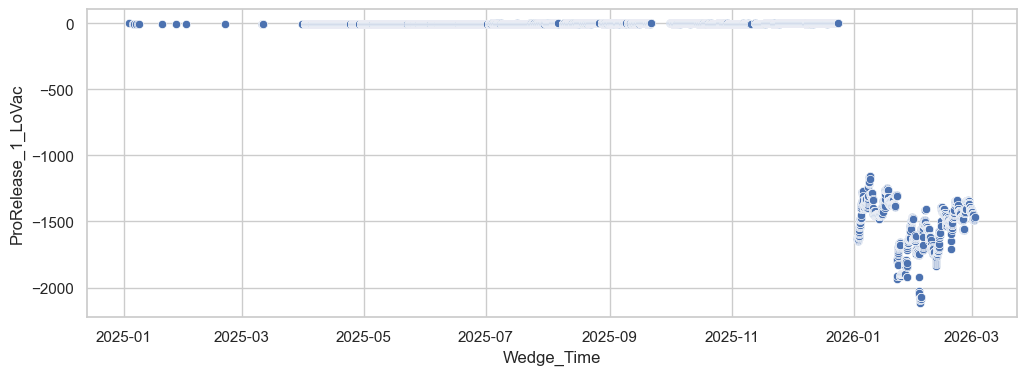

In [68]:
sns.scatterplot(turnup_data, x="Wedge_Time", y="ProRelease_1_LoVac")

In [69]:
[v for v in turnup_data.columns if "zero" in v.lower()]

['DG_4-5_zero_level',
 'DG_4-5_zero_level_(Pa)',
 'DG_1-3_zero_point',
 'DG1_zero_point',
 'DG2-3_zero_point']

# Steam

In [ ]:
[["DG1_zero_point", 'DG2-3_zero_point']]

In [5]:
turnup_data = pd.read_parquet(f"data/costimier_turnup.parquet")
turnup_data = transform(turnup_data,"Steam__kWh/T_")

In [1]:
fig = px.scatter(turnup_data[turnup_data.AB_Grade_ID==6010120].reset_index(), x="Wedge_Time", y="Steam__kWh/T_")
fig.show()

NameError: name 'px' is not defined

<Axes: xlabel='Wedge_Time', ylabel='Steam__kWh/T_'>

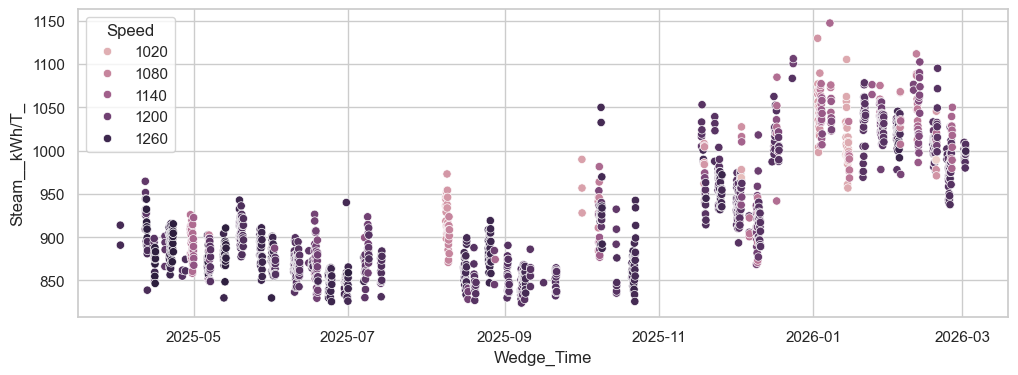

In [83]:
sns.scatterplot(turnup_data[turnup_data.AB_Grade_ID==6010120], y="Steam__kWh/T_", x="Wedge_Time", hue="Speed")

In [2]:
turnup_data = pd.read_parquet(f"data/costimier_turnup.parquet")
ycol = "Steam__kWh/T_"
#ycol='Condensate_energy_from_paper_plant_to_power_plant'
grade = ""

lags = 0
time_aware = True
candidate_lags = None
use_holdout = True

created_vars=[            
            "Water_flow_Predryer",
            "Water_flow_Afterdryer",
            "Water_flow",
            "flow_diluted_starch",
            "Fibre__g/m2_",
            "Water_flow_Afterdryer_input", 
            "Water_flow_Afterdryer_output",
            "dewatering",
        ]



turnup_data = transform(turnup_data,ycol)

if len(created_vars)>0:
    fc = FeatureCreator(features_to_create=created_vars, features_to_keep= list(set(turnup_data.columns.to_list()+created_vars)))
    turnup_data = fc.fit_transform(turnup_data)
    fr = fc.features_required()
else:
    fr=[]


turnup_data = turnup_data[turnup_data['Steam_flow_to_PreDryers']<=70]
turnup_data = turnup_data[turnup_data.index>"2025-04-01 00:00:00"]
turnup_data = turnup_data[~outlier(turnup_data[ycol], option="PctClip")]

if ycol== 'Steam_flow_to_PreDryers' or True:
    turnup_data = turnup_data[~outlier(turnup_data["Water_flow_Predryer"], option="PctClip")]
if ycol== 'Steam_flow_to_AfterDryers' or True:
    turnup_data = turnup_data[turnup_data["Water_flow_Afterdryer"]<15.5 ]
    turnup_data = turnup_data[turnup_data["flow_diluted_starch"]<30]
if ycol== 'Condensate_energy_from_paper_plant_to_power_plant' or True:
    turnup_data = turnup_data[~((turnup_data.index>"2026-01-11 12:00") & (turnup_data.index<"2026-01-12 11:00"))]
    turnup_data = turnup_data[~((turnup_data.index>"2026-01-17 12:00") & (turnup_data.index<"2026-01-19 11:00"))]
    turnup_data = turnup_data[((turnup_data["Condensate_energy_from_paper_plant_to_power_plant"]<10) & (turnup_data["Condensate_energy_from_paper_plant_to_power_plant"]>5))]

turnup_data = turnup_data[turnup_data.DG4_Temperature_Inlet_Air > 100]

turnup_data = turnup_data[turnup_data.grammage.isin([85,90,95,100,110,115,120,125,130,135])]
turnup_data = turnup_data[turnup_data.paper_type.isin(["3200", "6010", "3300"])]

turnup_data["inverse_speed"] = 1 / (turnup_data["Speed_PD1"]**2)


turnup_ts =turnup_data.copy()
turnup_ts = turnup_ts.sort_index()

turnup_ts = turnup_ts[turnup_ts.index>"2025-11-15"]
turnup_ts["grammage"] = turnup_ts["grammage"].astype("category")

turnup_ts["ProRelease_2_LoVac_squared"] = turnup_ts["ProRelease_2_LoVac"]

exog_vars = list(set(control_vars['Steam_flow_to_AfterDryers'] + control_vars['Steam_flow_to_PreDryers'] + fr + ["grammage"] )) 

candidate_lags = None

extra_vars = ["AB_Grade_ID"]

X, y = make_design(turnup_ts, ycol, exog_vars + extra_vars, candidate_lags,y_lags=range(1,1))
time_aware=True
if time_aware:
    n = len(X)
    split = int(n*0.8)
    inner_cv = TimeSeriesSplit(n_splits=5)
    Xtr, Xte = X.iloc[:split], X.iloc[split:]
    ytr, yte = y.iloc[:split], y.iloc[split:]
else:
    inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y,test_size=0.20,shuffle=True,random_state=42)

if use_holdout:        
    outer_cv = [(np.arange(0, split), np.arange(split, n))]
else:        
    outer_cv = TimeSeriesSplit(n_splits=5) if time_aware else 5

tscv = TimeSeriesSplit(n_splits=5)


inlet_temp = ['DG1_temperature_Inlet_Air','DG2_temperature_Inlet_Air','DG3_temperature_Inlet_Air','DG4_Temperature_Inlet_Air','DG5_Temperature_Inlet_Air']
exhaus_mois=['DG1_Moisture_content_Outlet_Air', 'DG2_Moisture_content_Outlet_Air', 'DG4_Moisture_content_Outlet_Air','DG5_Moisture_content_Outlet_Air']
steam_pressure = [v for v in exog_vars if re.compile(r"cylinder.*steam_pressure", re.IGNORECASE).search(v)]
steam_diff_pressure = [v for v in exog_vars if re.compile(r"cylinder.*differential_pressure", re.IGNORECASE).search(v)]
vacuum_vars = [v for v in exog_vars if "vacuum" in v.lower()] 
gas_deculator = [v for v in exog_vars if "decu" in v.lower() and "gas" in v.lower()]
speed_vars = ['AD6_speed','AD7_speed_bottom','Speed','Forming_Wire_Speed','Speed_Size_Press','Speed_PD4_bottom', 'Speed_PD5_bottom','AD7_speed_top','Speed_PD1','Speed_PD3','Speed_PD2','Speed_PD4_top','Speed_PD5_top','Speed_press_section']
draw_vars = ['Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3']

black_list = ['DG3_Moisture_content_Outlet_Air', "Lip_settings", "grammage", 'Conductivity_white_water_B46'] 
#black_list = []

prep_speed = GroupwisePLSTransformer(
    pls_columns=speed_vars + draw_vars,
    #group_col="grammage",
    n_components=4,
    score_prefix="speed",
    remainder="passthrough",
)

prep_inlet = GroupwisePLSTransformer(
    pls_columns=inlet_temp,
    #group_col="grammage",
    n_components=2,
    score_prefix="inlet_temp",
    remainder="passthrough",
)

prep_exhaus_moisture = GroupwisePLSTransformer(
    pls_columns=exhaus_mois,
    #group_col="grammage",
    n_components=2,
    score_prefix="exha_mois",
    remainder="passthrough",
)

prep_drying = GroupwisePLSTransformer(
    pls_columns=inlet_temp + steam_pressure,
    #group_col="grammage",
    n_components=2,
    score_prefix="steam_pressure",
    remainder="passthrough",
)

prep_drying_diff = GroupwisePLSTransformer(
    pls_columns=steam_diff_pressure,
    #group_col="grammage",
    n_components=2,
    score_prefix="steam_diff_pressure",
    remainder="passthrough",
)

prep_vacuum = GroupwisePLSTransformer(
    pls_columns=vacuum_vars,
    #group_col="grammage",
    n_components=4,
    score_prefix="vacuum",
    remainder="passthrough",
)

prep_gas_deculator = GroupwisePLSTransformer(
    pls_columns=gas_deculator,
    #group_col="grammage",
    n_components=3,
    score_prefix="gas_decu",
    remainder="passthrough",
)

prep_total = GroupwisePLSTransformer(
    pls_columns=inlet_temp + steam_pressure + exhaus_mois,
    #group_col="grammage",
    n_components=4,
    score_prefix="drying",
    remainder="passthrough",
)

prep_pip= Pipeline([
                ("prep_exhamois", prep_exhaus_moisture),              
                ("prep_inlet", prep_inlet),
                #("prep_steam_pressure", prep_drying),
                ("prep_vacuum", prep_vacuum),  
                ("prep_gas_deculator",prep_gas_deculator),
                #("prep_speed", prep_speed),  
])

#prep_pip= Pipeline([("prep_total", prep_total)])

Xtr_ = prep_pip.fit_transform(Xtr, ytr)
Xte_ = prep_pip.transform(Xte)

X_ = pd.concat([Xtr_,Xte_],axis=0)


inlet_trafo= [f"{prep_inlet.score_prefix}_{i}" for i in range(1,prep_inlet.n_components+1)]
exhaus_trafo= [f"{prep_exhaus_moisture.score_prefix}_{i}" for i in range(1,prep_exhaus_moisture.n_components+1)]
steam_pressure_trafo= [f"{prep_drying.score_prefix}_{i}" for i in range(1,prep_drying.n_components+1)]
steam_diff_pressure_trafo= [f"{prep_drying_diff.score_prefix}_{i}" for i in range(1,prep_drying_diff.n_components+1)]
vacuum_trafo= [f"{prep_vacuum.score_prefix}_{i}" for i in range(1,prep_vacuum.n_components+1)] 
gas_decu_trafo= [f"{prep_gas_deculator.score_prefix}_{i}" for i in range(1,prep_gas_deculator.n_components+1)] 
total_trafo= [f"{prep_total.score_prefix}_{i}" for i in range(1,prep_total.n_components+1)]


fixed_features = ["Water_flow_Predryer","Water_flow_Afterdryer_input", "grammage"] 
exog_vars_ = fixed_features + [v for v in exog_vars if v not in black_list and v not in fr]
exog_vars_ = list(set(exog_vars_) - set(steam_pressure + steam_diff_pressure))
for i in range(len(prep_pip.steps)):    
    _, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        #fixed_features += var_trafo
        exog_vars_ = list(set(exog_vars_ + var_trafo) - set(var_in))
fixed_features += inlet_trafo
exog_vars_ = list(set(fixed_features + exog_vars_) )


fixed_idx = [exog_vars_.index(f) for f in fixed_features]



k_target = 25
 
# -----------------------------
# RUN (your call, adjusted)
# -----------------------------
res = cmaes_feature_selection_exact_k(
    X_[exog_vars_], np.array(y).ravel(),
    var_names = exog_vars_,
    outer_cv=outer_cv,
    base_estimator=None,
    k_target= k_target, #len(fixed_features), #k_target
    selection="topk",        # or "weightedk"
    #selection="weightedk",        # or "topk"
    max_evals=3000,
    sigma0=1.0,
    seed=42,                 # keep fixed for apples-to-apples comparisons
    verbose=True,
    report_every_gen=1,
    popsize=24,            # None -> scaled default-like popsize; or set e.g. 16/24/32
    fixed_idx=fixed_idx,
    expected_sign={"DG1_temperature_Inlet_Air":-1,"DG2_temperature_Inlet_Air":-1},
    enable_penalty=False,
    weight_penalty=0.1,
)
 
selected_features = [exog_vars_[i] for i in res["selected_idx"]]
print("Selected n =", len(selected_features))
print("Selected features:", selected_features)
 
best_model = res["final_estimator"]
print(f"Done. n_evals={res['n_evals']}  popsize={res['popsize']}  best_loss={res['best_loss']:.5f} best_rmse={res['best_rmse']:.5f}")


NameError: name 'pd' is not defined

<Axes: >

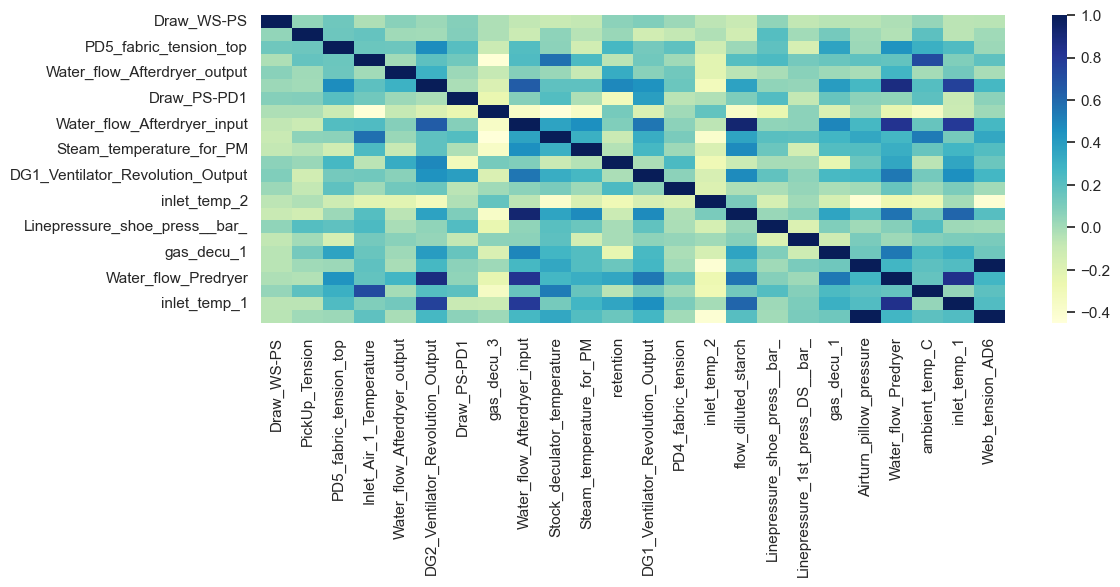

In [8]:
selected_features
sns.heatmap(X_[[v for v in selected_features if v!="grammage"]].corr(), cmap="YlGnBu")

In [18]:
from sklearn.base import BaseEstimator, TransformerMixin

class FastFeatureCreator(BaseEstimator, TransformerMixin):
    def __init__(self, features_to_create=None, features_to_keep=None, errors="raise", copy=True):
        self.features_to_create = features_to_create
        self.features_to_keep = features_to_keep
        self.errors = errors
        self.copy = copy

    def fit(self, X, y=None):
        if not hasattr(X, "columns"):
            raise ValueError("FastFeatureCreator expects a pandas DataFrame at fit.")

        self.feature_names_in_ = np.asarray(X.columns, dtype=object)

        registry = self._registry()
        requested = list(registry) if self.features_to_create is None else list(self.features_to_create)

        # cache dependency expansion once
        self.to_make_ = self._expand_with_deps(requested)

        # keep stable order
        if self.features_to_keep is None:
            self.features_to_keep_ = None
        else:
            self.features_to_keep_ = list(dict.fromkeys(self.features_to_keep))

        return self

    def transform(self, X):
        if not hasattr(self, "to_make_"):
            self.fit(X)

        X_df = self._to_dataframe(X)

        # one controlled copy only
        if self.copy:
            X_df = X_df.copy()

        registry = self._registry()

        for name in self.to_make_:
            if name in X_df.columns:
                continue

            fn = registry.get(name)
            if fn is None:
                if self.errors == "raise":
                    raise ValueError(f"Unknown engineered feature: {name}")
                continue

            try:
                fn(X_df)
            except Exception:
                if self.errors == "raise":
                    raise

        if self.features_to_keep_ is None:
            return X_df

        return X_df.loc[:, self.features_to_keep_]

    def get_feature_names_out(self, input_features=None):
        if self.features_to_keep is None:
            return np.asarray(self.feature_names_in_, dtype=object)
        return np.asarray(self.features_to_keep_, dtype=object)

    def _to_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X

        return pd.DataFrame(X, columns=list(self.feature_names_in_))

    @classmethod
    def _deps(cls):
        return {
            "Fibre__g/m2_": ["Starch_uptake__g/m2_"],
            "Water_flow": ["Water_flow_Predryer", "Water_flow_Afterdryer"],
            "Water_flow_Afterdryer_input": ["flow_diluted_starch"],
        }

    def _expand_with_deps(self, requested):
        deps = self._deps()
        seen = set()
        order = []

        def visit(f):
            if f in seen:
                return
            seen.add(f)
            for d in deps.get(f, []):
                visit(d)
            order.append(f)

        for f in requested:
            visit(f)

        return order

    # ---------- feature formulas ----------

    @staticmethod
    def _safe_inverse(s, eps=1e-9):
        # faster than pd.to_numeric if your columns are already numeric
        arr = s.to_numpy(dtype=float, copy=False)
        out = np.empty_like(arr, dtype=float)

        mask = np.abs(arr) > eps
        out[mask] = 1.0 / arr[mask]
        out[~mask] = np.nan

        return out

    @staticmethod
    def _add_starch_uptake(df):
        df.loc[:, "Starch_uptake__g/m2_"] = (
            df["Starch_uptake_by_paper_Top_Roll__g/m2_"].to_numpy(copy=False)
            + df["Starch_uptake_by_paper_Bottom_Roll__g/m2_"].to_numpy(copy=False)
        )

    @staticmethod
    def _add_fibre(df):
        df.loc[:, "Fibre__g/m2_"] = (
            df["Current_basis_weight"].to_numpy(copy=False)
            * (1.0 - df["Current_reel_moisture_average(reel)"].to_numpy(copy=False) / 100.0)
            - df["Starch_uptake__g/m2_"].to_numpy(copy=False)
        )

    @staticmethod
    def _add_water_flow_predryer(df):
        df.loc[:, "Water_flow_Predryer"] = (
            df["Current_basis_weight"].to_numpy(copy=False)
            * df["Speed_PD1"].to_numpy(copy=False)
            * df["Current_reel_width"].to_numpy(copy=False)
            * (65.0 - df["Moisture_out_of_PreDryer"].to_numpy(copy=False))
            * 60.0
            / 1e10
        )

    @staticmethod
    def _add_water_flow_afterdryer(df):
        df.loc[:, "Water_flow_Afterdryer"] = (
            df["Current_basis_weight"].to_numpy(copy=False)
            * df["Speed_PD1"].to_numpy(copy=False)
            * df["Current_reel_width"].to_numpy(copy=False)
            * (
                df["Moisture_after_SpeedSizer"].to_numpy(copy=False)
                - df["Actual_moisture"].to_numpy(copy=False)
            )
            * 60.0
            / 1e10
        )

    @staticmethod
    def _add_water_flow(df):
        df.loc[:, "Water_flow"] = (
            df["Water_flow_Predryer"].to_numpy(copy=False)
            + df["Water_flow_Afterdryer"].to_numpy(copy=False)
        )

    @staticmethod
    def _add_flow_diluted_starch(df):
        df.loc[:, "flow_diluted_starch"] = (
            df["Starch_uptake_by_paper_Top_Roll__g/m2_"].to_numpy(copy=False)
            / df["concentration_starch_working_tank_2"].to_numpy(copy=False)
            + df["Starch_uptake_by_paper_Bottom_Roll__g/m2_"].to_numpy(copy=False)
            / df["concentration_starch_working_tank_1"].to_numpy(copy=False)
        )

    @staticmethod
    def _add_flow_diluted_starch_index(df):
        df.loc[:, "flow_diluted_starch_index"] = (
            (
                df["Flow_starch_main_line_to_working_tank_2~^0"].to_numpy(copy=False)
                / df["concentration_starch_working_tank_2"].to_numpy(copy=False)
                + df["Flow_starch_main_line_to_working_tank_1~^0"].to_numpy(copy=False)
                / df["concentration_starch_working_tank_1"].to_numpy(copy=False)
            )
            / df["Production_Rate__T/h_"].to_numpy(copy=False)
        )

    @staticmethod
    def _add_water_flow_afterdryer_input(df):
        df.loc[:, "Water_flow_Afterdryer_input"] = (
            df["Current_basis_weight"].to_numpy(copy=False)
            * df["Speed_PD1"].to_numpy(copy=False)
            * df["Current_reel_width"].to_numpy(copy=False)
            * df["flow_diluted_starch"].to_numpy(copy=False)
            * 60.0
            / 1e10
        )

    @staticmethod
    def _add_water_flow_afterdryer_output(df):
        df.loc[:, "Water_flow_Afterdryer_output"] = (
            df["Current_basis_weight"].to_numpy(copy=False)
            * df["Speed_PD1"].to_numpy(copy=False)
            * df["Current_reel_width"].to_numpy(copy=False)
            * (
                df["Current_reel_moisture_average(reel)"].to_numpy(copy=False)
                - df["Moisture_out_of_PreDryer"].to_numpy(copy=False)
            )
            * 60.0
            / 1e10
        )

    @staticmethod
    def _add_inv_rod_pressure_bottom_roll(df):
        df.loc[:, "inv_Rod_Pressure_Bottom_Roll"] = FastFeatureCreator._safe_inverse(
            df["Rod_Pressure_Bottom_Roll"]
        )

    @staticmethod
    def _add_inv_rod_pressure_top_roll(df):
        df.loc[:, "inv_Rod_pressure_Top_Roll"] = FastFeatureCreator._safe_inverse(
            df["Rod_pressure_Top_Roll"]
        )

    @staticmethod
    def _add_square_rod_pressure_bottom_roll(df):
        x = df["Rod_Pressure_Bottom_Roll"].to_numpy(dtype=float, copy=False)
        df.loc[:, "square_Rod_Pressure_Bottom_Roll"] = x * x

    @staticmethod
    def _add_square_rod_pressure_top_roll(df):
        x = df["Rod_pressure_Top_Roll"].to_numpy(dtype=float, copy=False)
        df.loc[:, "square_Rod_pressure_Top_Roll"] = x * x

    @staticmethod
    def _add_dewatering(df):
        cols = [
            "Dewatering_Shoe_press",
            "Dewatering_Suction_Press_Roll",
            "Dewatering_top_wire_suction_box_zone_2",
            "Total_Dewatering_Press",
            "Dewatering_First_Press_Roll",
        ]

        arr = df.loc[:, cols].to_numpy(dtype=float, copy=False)
        df.loc[:, "dewatering"] = arr.sum(axis=1)

    @classmethod
    def _registry(cls):
        return {
            "Starch_uptake__g/m2_": cls._add_starch_uptake,
            "Fibre__g/m2_": cls._add_fibre,
            "Water_flow_Predryer": cls._add_water_flow_predryer,
            "Water_flow_Afterdryer": cls._add_water_flow_afterdryer,
            "Water_flow": cls._add_water_flow,
            "flow_diluted_starch": cls._add_flow_diluted_starch,
            "flow_diluted_starch_index": cls._add_flow_diluted_starch_index,
            "Water_flow_Afterdryer_input": cls._add_water_flow_afterdryer_input,
            "Water_flow_Afterdryer_output": cls._add_water_flow_afterdryer_output,
            "inv_Rod_Pressure_Bottom_Roll": cls._add_inv_rod_pressure_bottom_roll,
            "inv_Rod_pressure_Top_Roll": cls._add_inv_rod_pressure_top_roll,
            "square_Rod_Pressure_Bottom_Roll": cls._add_square_rod_pressure_bottom_roll,
            "square_Rod_pressure_Top_Roll": cls._add_square_rod_pressure_top_roll,
            "dewatering": cls._add_dewatering,
        }

In [9]:

s_vars=selected_features
features_to_keep_feat = s_vars
features_to_keep_filter = s_vars
for i in range(len(prep_pip.steps)):    
    _, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        s_vars_step = list(set(s_vars).intersection(set(var_trafo)))
        
        if len(s_vars_step) > 0:
            
            s_vars = list(set(s_vars) - set(s_vars_step) ) 
            features_to_keep_feat = list(set(features_to_keep_feat) - set(s_vars_step)) 
            features_to_keep_filter = list(set(features_to_keep_filter) - set(s_vars_step)) 
            features_to_keep_feat = features_to_keep_feat + var_in
            features_to_keep_filter = features_to_keep_filter + s_vars_step
    
features_to_create = [v for v in created_vars if v in  s_vars]
n_max=len(s_vars)

max_comps = 10 # min(20, len(exog_vars))
pre_estimator = Pipeline(steps=[])
pre_estimator.steps.append(("feat", FeatureCreator(features_to_create=features_to_create, features_to_keep=list(set(features_to_keep_feat)) ,errors="raise")))
for i in range(len(prep_pip.steps)):
    name_step, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        if len(list(set(features_to_keep_filter).intersection(set(var_trafo)))) > 0:        
            pre_estimator.steps.append((name_step, step))
    else:
        pre_estimator.steps.append((name_step, step))
#pre_estimator.steps.append(("filter", FeatureCreator(features_to_create=[], features_to_keep=list(set(features_to_keep_filter)),errors="raise")))
pre_estimator.steps.append(("filter", ColumnSelector(list(set(features_to_keep_filter)))))

main_estimator= make_estimator_for_selected(features_to_keep_filter)

estimator = Pipeline(pre_estimator.steps + main_estimator.steps)


In [10]:
features_to_keep_filter

['Draw_WS-PS',
 'inlet_temp_2',
 'PickUp_Tension',
 'flow_diluted_starch',
 'grammage',
 'PD5_fabric_tension_top',
 'Linepressure_shoe_press__bar_',
 'Inlet_Air_1_Temperature',
 'Water_flow_Afterdryer_output',
 'DG2_Ventilator_Revolution_Output',
 'Draw_PS-PD1',
 'Linepressure_1st_press_DS__bar_',
 'Airturn_pillow_pressure',
 'Steam_temperature_for_PM',
 'Water_flow_Afterdryer_input',
 'Stock_deculator_temperature',
 'retention',
 'DG1_Ventilator_Revolution_Output',
 'Water_flow_Predryer',
 'ambient_temp_C',
 'PD4_fabric_tension',
 'inlet_temp_1',
 'Web_tension_AD6',
 'gas_decu_1',
 'gas_decu_3']

In [ ]:
param_grid={"ridge__alpha": np.logspace(1, 3, 100)}
#param_grid = {"pca__base_estimator__n_components": list(range(1, max_comps + 1)), "ridge__alpha":  np.logspace(-4, 3, 20)}

    
model = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    refit=True,            # refit best model on all training data
)

if "feat" in model.estimator.named_steps:
    fr = model.estimator.named_steps["feat"].features_required()
    sv = [v for v in features_to_keep_feat if v not in features_to_create]
    sel_vars=list(set(fr + sv))
    model.fit(Xtr[sel_vars],ytr)
else:    
    sel_vars=s_vars
    model.fit(Xtr[sel_vars],ytr)

In [21]:
model.best_params_

{'ridge__alpha': np.float64(225.70197196339214)}

 Test Set Performance
RMSE : 24.8606
MAE  : 18.7560
R²   : 0.7961


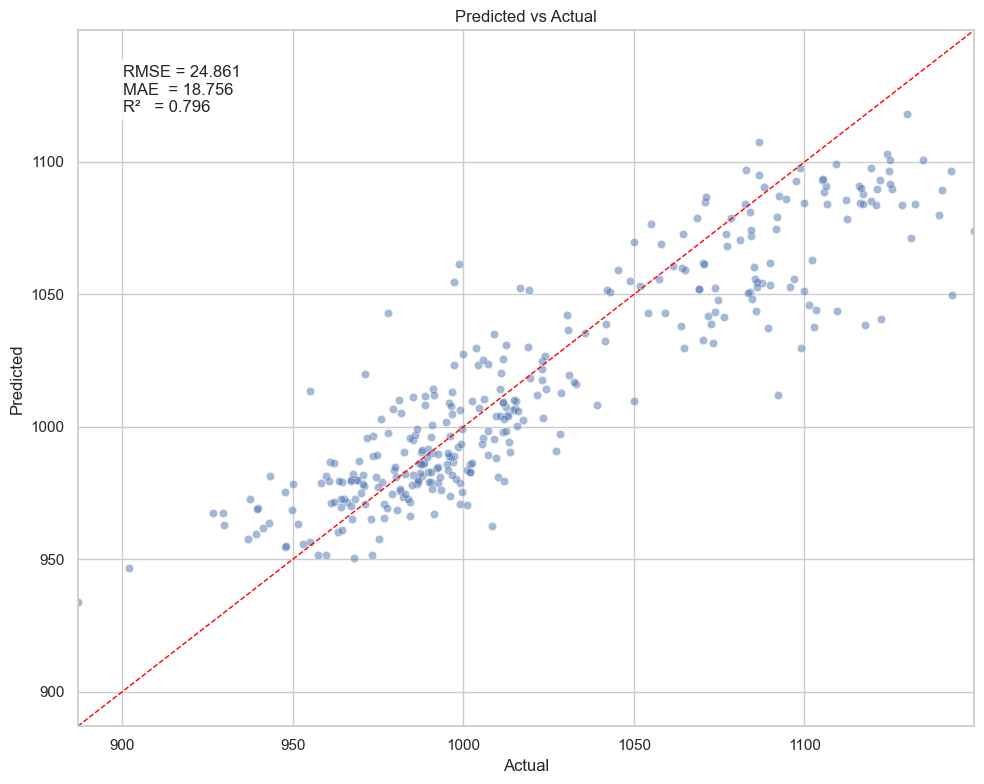

In [22]:
ypred = model.predict(Xte[sel_vars])
# metrics
rmse = root_mean_squared_error(yte, ypred)
mae = mean_absolute_error(yte, ypred)
r2 = r2_score(yte, ypred)
 
# pretty print in console
print("="*40)
print(" Test Set Performance")
print("="*40)
print(f"RMSE : {rmse:,.4f}")
print(f"MAE  : {mae:,.4f}")
print(f"R²   : {r2:,.4f}")
print("="*40)
 
# scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
 
sns.scatterplot(x=yte, y=ypred, alpha=0.5, ax=ax)
 
lims = [
    np.nanmin([yte.min(), ypred.min()]),
    np.nanmax([yte.max(), ypred.max()])
]
 
ax.plot(lims, lims, linestyle="--", color="red", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
 
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs Actual")
 
# add metrics box inside plot
textstr = "\n".join((
    f"RMSE = {rmse:.3f}",
    f"MAE  = {mae:.3f}",
    f"R²   = {r2:.3f}",
))
 
ax.text(
    0.05, 0.95,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
 
plt.tight_layout()
plt.show()

In [39]:
from utility import calculate_manual_shap, plotly_shap_beeswarm

base, shap_vals, X_explain, feats = calculate_manual_shap(model.best_estimator_, X_reference=Xtr[sel_vars+["AB_Grade_ID"]], X_sample=Xte[sel_vars+["AB_Grade_ID"]], grade_id=6010120, grade_col="AB_Grade_ID")

PermutationExplainer explainer: 126it [01:06,  1.83it/s]                         


In [40]:
fig = plotly_shap_beeswarm(shap_vals, X_explain, feats, max_features=100)
fig.show()

In [41]:
if "feat" in model.estimator.named_steps:
    fr = model.estimator.named_steps["feat"].features_required()
    sv = [v for v in features_to_keep_feat if v not in features_to_create]
    sel_vars=list(set(fr + sv))
    model.best_estimator_.fit(X[sel_vars],y)
else:    
    sel_vars=s_vars
    model.best_estimator_.fit(X[sel_vars],y)

In [15]:
with open(f"steam_model_{k_target}.pkl", 'wb') as f:
        pickle.dump(model, f)

In [13]:
import time
import pandas as pd

def profile_pipeline_predict(pipe, X, repeat=3):
    rows = []

    for _ in range(repeat):
        Xt = X.copy()
        for name, step in pipe.steps[:-1]:
            t0 = time.perf_counter()
            Xt = step.transform(Xt)
            rows.append({
                "step": name,
                "seconds": time.perf_counter() - t0,
                "shape": getattr(Xt, "shape", None),
                "type": type(Xt).__name__,
            })

        t0 = time.perf_counter()
        _ = pipe.steps[-1][1].predict(Xt)
        rows.append({
            "step": pipe.steps[-1][0],
            "seconds": time.perf_counter() - t0,
            "shape": getattr(Xt, "shape", None),
            "type": type(Xt).__name__,
        })

    return (
        pd.DataFrame(rows)
        .groupby("step", as_index=False)["seconds"]
        .mean()
        .sort_values("seconds", ascending=False)
    )

In [14]:
bm1 = profile_pipeline_predict(model.best_estimator_, Xte[sel_vars], repeat=1000)
bm1

,step,seconds
0,feat,0.003236
2,prep,0.002597
4,prep_inlet,0.001816
5,prep_vacuum,0.001688
3,prep_gas_deculator,0.001592
1,filter,0.000373
6,ridge,0.000123


In [30]:
bm1 = profile_pipeline_predict(model.best_estimator_, Xte[sel_vars], repeat=1000)
bm1

,step,seconds
0,feat,0.002958
2,prep,0.002347
4,prep_inlet,0.001674
5,prep_vacuum,0.001592
3,prep_gas_deculator,0.001497
1,filter,0.000349
6,ridge,0.000109


In [32]:
bm1.seconds.sum()

np.float64(0.010526660399977118)

In [36]:
t0 = time.perf_counter()
for i in range(100):
    _ = model.best_estimator_.predict(Xte[sel_vars])
print(time.perf_counter() - t0)

1.2092270000139251


# Electricity

In [53]:
[v for v in turnup_data.columns if "draw" in v.lower()]

['Draw_PD5-SS',
 'Draw_AD7-PR',
 'Draw_AD6-AD7',
 'Draw_PD4-PD5',
 'Draw_WS-PS',
 'Draw_PD1-PD2',
 'Draw_PD3-PD4',
 'Draw_SS-AD6',
 'Total_draw_measurement_pope_reel',
 'Draw_PS-PD1',
 'Draw_PD2-PD3']

In [ ]:
turnup_data = pd.read_parquet(f"data/costimier_turnup.parquet")
ycol = "Electricity__kWh/T_"
#ycol='Condensate_energy_from_paper_plant_to_power_plant'
grade = ""

lags = 0
time_aware = True
candidate_lags = None
use_holdout = True

created_vars=[            
            "Water_flow_Predryer",
            "Water_flow_Afterdryer",
            "Water_flow",
            "flow_diluted_starch",
            "Fibre__g/m2_",
            "Water_flow_Afterdryer_input", 
            "Water_flow_Afterdryer_output",
            "dewatering",
        ]



turnup_data = transform(turnup_data,ycol)

if len(created_vars)>0:
    fc = FeatureCreator(features_to_create=created_vars, features_to_keep= list(set(turnup_data.columns.to_list()+created_vars)))
    turnup_data = fc.fit_transform(turnup_data)
    fr = fc.features_required()
else:
    fr=[]


turnup_data = turnup_data[turnup_data['Steam_flow_to_PreDryers']<=70]
turnup_data = turnup_data[~outlier(turnup_data[ycol], option="PctClip")]

if ycol== 'Steam_flow_to_PreDryers' or True:
    turnup_data = turnup_data[~outlier(turnup_data["Water_flow_Predryer"], option="PctClip")]
if ycol== 'Steam_flow_to_AfterDryers' or True:
    turnup_data = turnup_data[turnup_data["Water_flow_Afterdryer"]<15.5 ]
    turnup_data = turnup_data[turnup_data["flow_diluted_starch"]<30]
if ycol== 'Condensate_energy_from_paper_plant_to_power_plant' or True:
    turnup_data = turnup_data[~((turnup_data.index>"2026-01-11 12:00") & (turnup_data.index<"2026-01-12 11:00"))]
    turnup_data = turnup_data[~((turnup_data.index>"2026-01-17 12:00") & (turnup_data.index<"2026-01-19 11:00"))]
    turnup_data = turnup_data[((turnup_data["Condensate_energy_from_paper_plant_to_power_plant"]<10) & (turnup_data["Condensate_energy_from_paper_plant_to_power_plant"]>5))]

turnup_data = turnup_data[turnup_data.DG4_Temperature_Inlet_Air > 100]

turnup_data = turnup_data[turnup_data.grammage.isin([85,90,95,100,110,115,120,125,130,135])]
turnup_data = turnup_data[turnup_data.paper_type.isin(["3200", "6010", "3300"])]

turnup_data["inverse_speed"] = 1 / (turnup_data["Speed_PD1"]**2)


turnup_ts =turnup_data.copy()
turnup_ts = turnup_ts.sort_index()

#turnup_ts = turnup_ts[turnup_ts.index>"2025-11-15"]
turnup_ts["grammage"] = turnup_ts["grammage"].astype("category")

exog_vars = list(set(control_vars["Electricity__kWh/T_"] + fr + ["grammage"])) + ["dewatering"]

candidate_lags = None

extra_vars = ["AB_Grade_ID"]

X, y = make_design(turnup_ts, ycol, exog_vars + extra_vars, candidate_lags,y_lags=range(1,1))
time_aware=True
if time_aware:
    n = len(X)
    split = int(n*0.8)
    inner_cv = TimeSeriesSplit(n_splits=5)
    Xtr, Xte = X.iloc[:split], X.iloc[split:]
    ytr, yte = y.iloc[:split], y.iloc[split:]
else:
    inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y,test_size=0.20,shuffle=True,random_state=42)

if use_holdout:        
    outer_cv = [(np.arange(0, split), np.arange(split, n))]
else:        
    outer_cv = TimeSeriesSplit(n_splits=5) if time_aware else 5

tscv = TimeSeriesSplit(n_splits=5)


speed_vars = ['AD6_speed','AD7_speed_bottom','Speed','Forming_Wire_Speed','Speed_Size_Press','Speed_PD4_bottom', 'Speed_PD5_bottom','AD7_speed_top','Speed_PD1','Speed_PD3','Speed_PD2','Speed_PD4_top','Speed_PD5_top','Speed_press_section']
vacuum_vars = [v for v in exog_vars if "vacuum" in v.lower()] 
draw_vars = ['Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3']
speedsizer_linepressure_vars = ["SpeedSizer_Linepressure_DS","SpeedSizer_Linepressure_FS"]
linepressure_vars=["Linepressure_1st_press_FS__bar_", "Linepressure_2nd_press_FS__bar_", "Linepressure_1st_press_DS__bar_","Linepressure_2nd_press_DS__bar_", "Linepressure_shoe_press__bar_"]
  
#black_list = ['Thick_Stock_Consistency__%_', "grammage", "Consistency_starch_main_line"]
black_list = ['Thick_Stock_Consistency__%_', "Consistency_starch_main_line", 'Conductivity_white_water_B46']

prep_speed = GroupwisePLSTransformer(
    pls_columns=speed_vars + draw_vars,
    #group_col="grammage",
    n_components=4,
    score_prefix="speed",
    remainder="passthrough",
)

prep_vacuum = GroupwisePLSTransformer(
    pls_columns=vacuum_vars,
    #group_col="grammage",
    n_components=4,
    score_prefix="vacuum",
    remainder="passthrough",
)

prep_draw = GroupwisePLSTransformer(
    pls_columns=draw_vars,
    #group_col="grammage",
    n_components=2,
    score_prefix="draw",
    remainder="passthrough",
)

prep_speedsizer_linepressure = GroupwisePLSTransformer(
    pls_columns=speedsizer_linepressure_vars,
    #group_col="grammage",
    n_components=1,
    score_prefix="speedsizer_linepressure",
    remainder="passthrough",
)

prep_linepressure = GroupwisePLSTransformer(
    pls_columns=linepressure_vars,
    #group_col="grammage",
    n_components=1,
    score_prefix="linepressure",
    remainder="passthrough",
)



prep_pip= Pipeline([
                ("prep_speed", prep_speed), 
                ("prep_vacuum", prep_vacuum), 
                #("prep_draw", prep_draw), 
                ("prep_speedsizer_linepressure", prep_speedsizer_linepressure), 
                ("prep_linepressure", prep_linepressure), 
                
])

#prep_pip= Pipeline([("prep_total", prep_total)])

Xtr_ = prep_pip.fit_transform(Xtr, ytr)
Xte_ = prep_pip.transform(Xte)

X_ = pd.concat([Xtr_,Xte_],axis=0)


speed_trafo= [f"{prep_speed.score_prefix}_{i}" for i in range(1,prep_speed.n_components+1)]



fixed_features = ["retention"] #["grammage"]
exog_vars_ = fixed_features + [v for v in exog_vars if v not in black_list and v not in fr]
#exog_vars_ = list(set(exog_vars_) - set(steam_pressure + steam_diff_pressure))
for i in range(len(prep_pip.steps)):    
    _, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        #fixed_features += var_trafo
        exog_vars_ = list(set(exog_vars_ + var_trafo) - set(var_in))
#fixed_features += inlet_trafo
exog_vars_ = list(set(fixed_features + exog_vars_) )


fixed_idx = [exog_vars_.index(f) for f in fixed_features]



k_target = 8
 
# -----------------------------
# RUN (your call, adjusted)
# -----------------------------
res = cmaes_feature_selection_exact_k(
    X_[exog_vars_], np.array(y).ravel(),
    var_names = exog_vars_,
    outer_cv=outer_cv,
    base_estimator=None,
    k_target= k_target,#len(fixed_features), #k_target
    selection="topk",        # or "weightedk"
    #selection="weightedk",        # or "topk"
    max_evals=1000,
    sigma0=1.0,
    seed=42,                 # keep fixed for apples-to-apples comparisons
    verbose=True,
    report_every_gen=1,
    popsize=24,            # None -> scaled default-like popsize; or set e.g. 16/24/32
    fixed_idx=fixed_idx,
    expected_sign={"DG1_temperature_Inlet_Air":-1,"DG2_temperature_Inlet_Air":-1},
    enable_penalty=False,
    weight_penalty=0.1,
)
 
selected_features = [exog_vars_[i] for i in res["selected_idx"]]
print("Selected n =", len(selected_features))
print("Selected features:", selected_features)
 
best_model = res["final_estimator"]
print(f"Done. n_evals={res['n_evals']}  popsize={res['popsize']}  best_loss={res['best_loss']:.5f} best_rmse={res['best_rmse']:.5f}")


CMA-ES evals (k_free=7):   0%|          | 0/1000 [00:00<?, ?it/s]

NEW BEST: loss=9.70430 rmse=9.70430k_full=8 k_free=7 evals=1
NEW BEST: loss=6.51717 rmse=6.51717k_full=8 k_free=7 evals=2
NEW BEST: loss=6.42152 rmse=6.42152k_full=8 k_free=7 evals=31
NEW BEST: loss=6.40363 rmse=6.40363k_full=8 k_free=7 evals=62
NEW BEST: loss=6.32131 rmse=6.32131k_full=8 k_free=7 evals=63
NEW BEST: loss=6.11186 rmse=6.11186k_full=8 k_free=7 evals=124
NEW BEST: loss=6.10595 rmse=6.10595k_full=8 k_free=7 evals=152
NEW BEST: loss=5.98370 rmse=5.98370k_full=8 k_free=7 evals=160
termination on {'tolflatfitness': 1}
final/bestever f-value = 5.983698e+00 5.983698e+00 after 744/160 evaluations
incumbent solution: [ -6.97992342  -4.57146503 -14.90218416  12.18017115   7.45186001
  -2.79940451  -1.43374134 -11.19440139 ...]
std deviations: [2.85984849 2.7902984  3.70466952 3.1307103  3.05919695 2.5934428
 2.71040484 3.3462694  ...]
Selected n = 8
Selected features: ['retention', 'vacuum_4', 'vacuum_3', 'PickUp_Tension', 'grammage', 'speed_1', 'vacuum_2', 'pH_measurement_white_w

<Axes: >

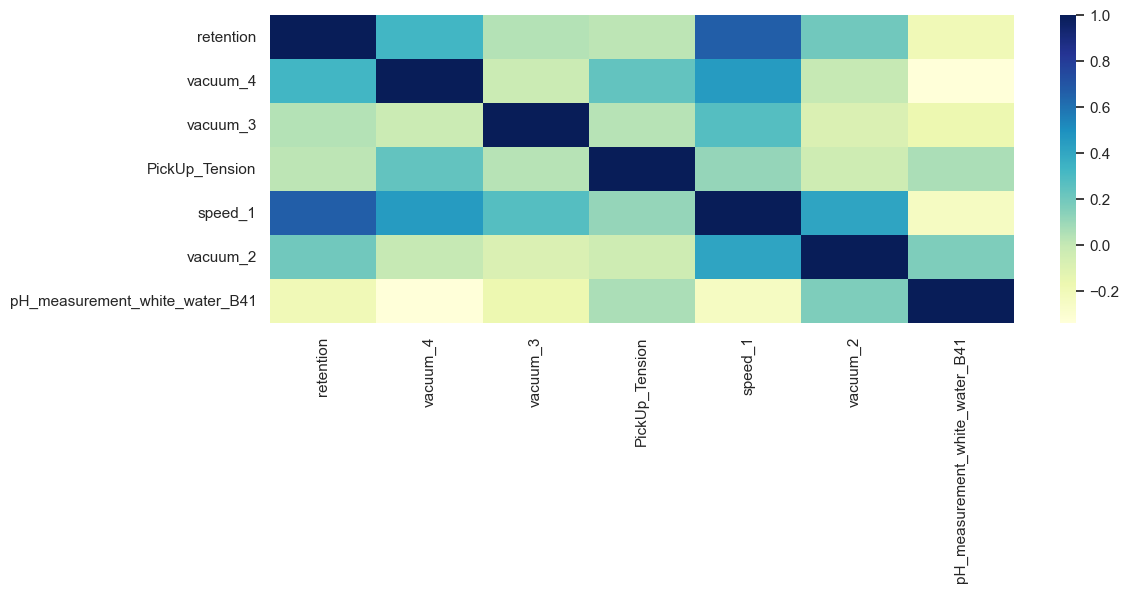

In [11]:
selected_features
sns.heatmap(X_[[v for v in selected_features if v!="grammage"]].corr(), cmap="YlGnBu")

In [ ]:
s_vars=selected_features
features_to_keep_feat = s_vars
features_to_keep_filter = s_vars
for i in range(len(prep_pip.steps)):    
    _, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        s_vars_step = list(set(s_vars).intersection(set(var_trafo)))
        
        if len(s_vars_step) > 0:
            
            s_vars = list(set(s_vars) - set(s_vars_step) ) 
            features_to_keep_feat = list(set(features_to_keep_feat) - set(s_vars_step)) 
            features_to_keep_filter = list(set(features_to_keep_filter) - set(s_vars_step)) 
            features_to_keep_feat = features_to_keep_feat + var_in
            features_to_keep_filter = features_to_keep_filter + s_vars_step
    
features_to_create = [v for v in created_vars if v in  s_vars]
n_max=len(s_vars)

max_comps = 10 # min(20, len(exog_vars))
pre_estimator = Pipeline(steps=[])
pre_estimator.steps.append(("feat", FeatureCreator(features_to_create=features_to_create, features_to_keep=list(set(features_to_keep_feat)) ,errors="raise")))
for i in range(len(prep_pip.steps)):
    name_step, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        if len(list(set(features_to_keep_filter).intersection(set(var_trafo)))) > 0:        
            pre_estimator.steps.append((name_step, step))
    else:
        pre_estimator.steps.append((name_step, step))
#pre_estimator.steps.append(("filter", FeatureCreator(features_to_create=[], features_to_keep=list(set(features_to_keep_filter)),errors="raise")))
pre_estimator.steps.append(("filter", ColumnSelector(list(set(features_to_keep_filter)))))

main_estimator= make_estimator_for_selected(features_to_keep_filter)

estimator = Pipeline(pre_estimator.steps + main_estimator.steps)


In [13]:
features_to_keep_filter

['PickUp_Tension',
 'grammage',
 'speed_1',
 'retention',
 'pH_measurement_white_water_B41',
 'vacuum_2',
 'vacuum_3',
 'vacuum_4']

In [14]:
param_grid={"ridge__alpha": np.logspace(1, 5, 100)}
#param_grid = {"pca__base_estimator__n_components": list(range(1, max_comps + 1)), "ridge__alpha":  np.logspace(-4, 3, 20)}

    
model = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    refit=True,            # refit best model on all training data
)

if "feat" in model.estimator.named_steps:
    fr = model.estimator.named_steps["feat"].features_required()
    sv = [v for v in features_to_keep_feat if v not in features_to_create]
    sel_vars=list(set(fr + sv))
    model.fit(Xtr[sel_vars],ytr)
else:    
    sel_vars=s_vars
    model.fit(Xtr[sel_vars],ytr)

In [16]:
model.best_params_

{'ridge__alpha': np.float64(10.0)}

 Test Set Performance
RMSE : 5.9837
MAE  : 4.4061
R²   : 0.9227


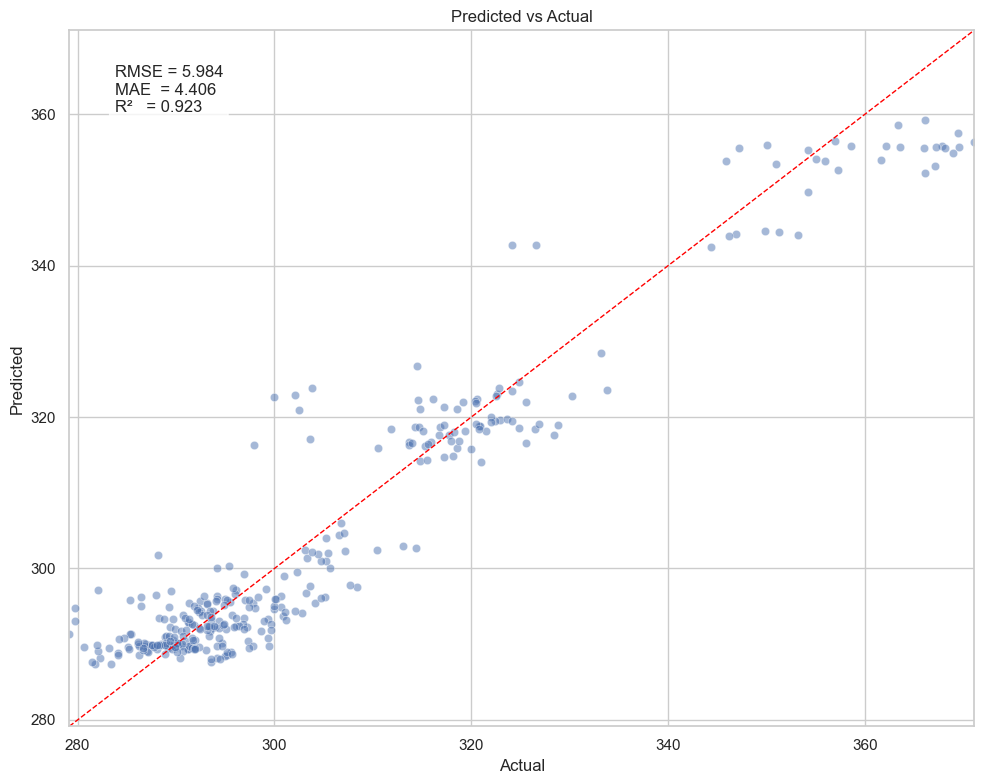

In [17]:
ypred = model.predict(Xte[sel_vars])
# metrics
rmse = root_mean_squared_error(yte, ypred)
mae = mean_absolute_error(yte, ypred)
r2 = r2_score(yte, ypred)
 
# pretty print in console
print("="*40)
print(" Test Set Performance")
print("="*40)
print(f"RMSE : {rmse:,.4f}")
print(f"MAE  : {mae:,.4f}")
print(f"R²   : {r2:,.4f}")
print("="*40)
 
# scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
 
sns.scatterplot(x=yte, y=ypred, alpha=0.5, ax=ax)
 
lims = [
    np.nanmin([yte.min(), ypred.min()]),
    np.nanmax([yte.max(), ypred.max()])
]
 
ax.plot(lims, lims, linestyle="--", color="red", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
 
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs Actual")
 
# add metrics box inside plot
textstr = "\n".join((
    f"RMSE = {rmse:.3f}",
    f"MAE  = {mae:.3f}",
    f"R²   = {r2:.3f}",
))
 
ax.text(
    0.05, 0.95,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
 
plt.tight_layout()
plt.show()

In [299]:
from utility import calculate_manual_shap, plotly_shap_beeswarm

base, shap_vals, X_explain, feats = calculate_manual_shap(model.best_estimator_, X_reference=Xtr[sel_vars+["AB_Grade_ID"]], X_sample=Xte[sel_vars+["AB_Grade_ID"]], grade_id=6010120, grade_col="AB_Grade_ID")

PermutationExplainer explainer: 126it [00:18,  3.39it/s]


In [301]:
fig = plotly_shap_beeswarm(shap_vals, X_explain, feats, max_features=100)
fig.show()

<Axes: xlabel='Thick_Stock_Consistency__%_', ylabel='Electricity__kWh/T_'>

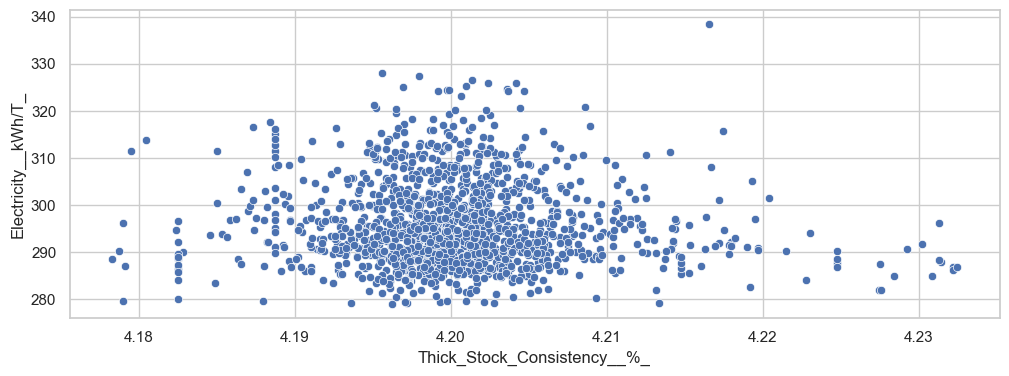

In [126]:
sns.scatterplot(turnup_data[turnup_data.AB_Grade_ID==6010120], x='Thick_Stock_Consistency__%_', y=ycol)

In [18]:
if "feat" in model.estimator.named_steps:
    fr = model.estimator.named_steps["feat"].features_required()
    sv = [v for v in features_to_keep_feat if v not in features_to_create]
    sel_vars=list(set(fr + sv))
    model.best_estimator_.fit(X[sel_vars],y)
else:    
    sel_vars=s_vars
    model.best_estimator_.fit(X[sel_vars],y)

In [19]:
with open(f"electricity_model.pkl", 'wb') as f:
        pickle.dump(model, f)

In [313]:
with open(f"electricity_model_{k_target}.pkl", 'wb') as f:
        pickle.dump(model, f)

# SCT CD

In [21]:
turnup_data = pd.read_parquet(f"data/costimier_turnup.parquet")


In [187]:
v =  'Bentonite_2_mass_flow__g/T_'
outlier_flag = detect_outliers(turnup_data,v,
                                    method="iqr",
                                    #group_col="AB_Grade_ID" 
                                    )
turnup_data["outlier"] = outlier_flag

fig = px.scatter(turnup_data.reset_index(), x="Wedge_Time", y=v,  color=turnup_data["outlier"].map({True:"Outlier", False:"Normal"}))
fig.show()

In [ ]:
turnup_data["Wedge_Time"]

In [53]:
from utility import update_turnup_grammage, ewm_reset

turnup_data = pd.read_parquet(f"data/costimier_turnup.parquet")
ycol = "MBS_SCT_CD"
grade = ""

lags = 0
time_aware = True
candidate_lags = None
use_holdout = True

created_vars=[
            "Starch_uptake__g/m2_",
            "Water_flow_Predryer",
            "Water_flow_Afterdryer",
            "Water_flow",
            "flow_diluted_starch",
            "Fibre__g/m2_",
            "Water_flow_Afterdryer_input", 
            "Water_flow_Afterdryer_output",
            "dewatering",
        ]

turnup_data = transform(turnup_data,ycol)

if len(created_vars)>0:
    fc = FeatureCreator(features_to_create=created_vars, features_to_keep= list(set(turnup_data.columns.to_list()+created_vars)))
    turnup_data = fc.fit_transform(turnup_data)
    fr = fc.features_required()
else:
    fr=[]


turnup_data = turnup_data[turnup_data['Steam_flow_to_PreDryers']<=70]
turnup_data = turnup_data[turnup_data.index>"2025-04-01 00:00:00"]
turnup_data = turnup_data[~outlier(turnup_data[ycol], option="PctClip")]

if ycol== 'Steam_flow_to_PreDryers' or True:
    turnup_data = turnup_data[~outlier(turnup_data["Water_flow_Predryer"], option="PctClip")]
if ycol== 'Steam_flow_to_AfterDryers' or True:
    turnup_data = turnup_data[turnup_data["Water_flow_Afterdryer"]<15.5 ]
    turnup_data = turnup_data[turnup_data["flow_diluted_starch"]<30]
if ycol== 'Condensate_energy_from_paper_plant_to_power_plant' or True:
    turnup_data = turnup_data[~((turnup_data.index>"2026-01-11 12:00") & (turnup_data.index<"2026-01-12 11:00"))]
    turnup_data = turnup_data[~((turnup_data.index>"2026-01-17 12:00") & (turnup_data.index<"2026-01-19 11:00"))]
    turnup_data = turnup_data[((turnup_data["Condensate_energy_from_paper_plant_to_power_plant"]<10) & (turnup_data["Condensate_energy_from_paper_plant_to_power_plant"]>5))]

turnup_data = turnup_data[turnup_data.DG4_Temperature_Inlet_Air > 100]

turnup_data = turnup_data[turnup_data.grammage.isin([85,90,95,100,110,115,120,125,130,135])]
turnup_data = turnup_data[turnup_data.paper_type.isin(["3200", "6010", "3300"])]

turnup_data["inverse_speed"] = 1 / (turnup_data["Speed_PD1"]**2)


turnup_ts =turnup_data.copy()
turnup_ts = turnup_ts.sort_index()

turnup_ts["Delta_basis_weight"] = turnup_ts["Current_basis_weight"] - turnup_ts["grammage"]
turnup_ts["grammage"] = turnup_ts["grammage"].astype("category")

update_turnup_grammage(turnup_ts)
turnup_ts["AB_Grade_ID"] = turnup_ts["AB_Grade_ID"].astype(int)

exog_vars = list(set(control_vars[ycol] + fr + ["grammage"])) + ["Delta_basis_weight"]

candidate_lags = None

extra_vars = ["AB_Grade_ID"]

lags = 0
filter = True

if filter:
    grade_change = turnup_ts["AB_Grade_ID"].ne(turnup_ts["AB_Grade_ID"].shift())
    gap12 = turnup_ts.index.to_series().diff().gt(pd.Timedelta("12h")).fillna(True)
    turnup_ts["seg"] = (grade_change | gap12).cumsum()

    for c in exog_vars + extra_vars + [ycol]:
        turnup_ts[c] = turnup_ts.groupby("seg", group_keys=False)[c].transform(ewm_reset)

for i in range(1,lags+1):
    exog_vars.append(f"y_L{i}")

X, y = make_design(turnup_ts, ycol, exog_vars + extra_vars, candidate_lags,y_lags=range(1,lags + 1))
time_aware=True
if time_aware:
    n = len(X)
    split = int(n*0.8)
    inner_cv = TimeSeriesSplit(n_splits=5)
    Xtr, Xte = X.iloc[:split], X.iloc[split:]
    ytr, yte = y.iloc[:split], y.iloc[split:]
else:
    inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y,test_size=0.20,shuffle=True,random_state=42)

if use_holdout:        
    outer_cv = [(np.arange(0, split), np.arange(split, n))]
else:        
    outer_cv = TimeSeriesSplit(n_splits=5) if time_aware else 5

tscv = TimeSeriesSplit(n_splits=5)


speed_vars = ['AD6_speed','AD7_speed_bottom','Speed','Forming_Wire_Speed','Speed_Size_Press','Speed_PD4_bottom', 'Speed_PD5_bottom','AD7_speed_top','Speed_PD1','Speed_PD3','Speed_PD2','Speed_PD4_top','Speed_PD5_top','Speed_press_section']
vacuum_vars = [v for v in exog_vars if "vacuum" in v.lower()] 
draw_vars = ['Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3']
speedsizer_linepressure_vars = ["SpeedSizer_Linepressure_DS","SpeedSizer_Linepressure_FS"]
linepressure_vars=["Linepressure_1st_press_FS__bar_", "Linepressure_2nd_press_FS__bar_", "Linepressure_1st_press_DS__bar_","Linepressure_2nd_press_DS__bar_", "Linepressure_shoe_press__bar_"]
conc_starch_vars = ["concentration_starch_working_tank_2", "concentration_starch_working_tank_1"]
  
#black_list = ['Thick_Stock_Consistency__%_', "grammage", "Consistency_starch_main_line"]
black_list = ['Thick_Stock_Consistency__%_', "Consistency_starch_main_line", 'Conductivity_white_water_B46', 'Bentonite_1_mass_flow__g/T_','Bentonite_2_mass_flow__g/T_',]

prep_draw = GroupwisePLSTransformer(
    pls_columns= draw_vars,
    #group_col="grammage",
    n_components=2,
    score_prefix="draw",
    remainder="passthrough",
)

prep_speedsizer_linepressure = GroupwisePLSTransformer(
    pls_columns=speedsizer_linepressure_vars,
    #group_col="grammage",
    n_components=1,
    score_prefix="speedsizer_linepressure",
    remainder="passthrough",
)

prep_linepressure = GroupwisePLSTransformer(
    pls_columns=linepressure_vars,
    #group_col="grammage",
    n_components=1,
    score_prefix="linepressure",
    remainder="passthrough",
)

prep_conc_starch = GroupwisePLSTransformer(
    pls_columns=conc_starch_vars,
    #group_col="grammage",
    n_components=1,
    score_prefix="conc_starch",
    remainder="passthrough",
)

prep_pip= Pipeline([
     ("prep_draw", prep_draw), 
     ("prep_speedsizer_linepressure",prep_speedsizer_linepressure),
     ("prep_linepressure",prep_linepressure),
     ("prep_conc_starch",prep_conc_starch)
                
])

#prep_pip= Pipeline([("prep_total", prep_total)])

Xtr_ = prep_pip.fit_transform(Xtr, ytr)
Xte_ = prep_pip.transform(Xte)

X_ = pd.concat([Xtr_,Xte_],axis=0)


fixed_features = ["grammage","Starch_uptake__g/m2_","Delta_basis_weight","Jet/wire_ratio"]#, "Current_reel_moisture_average(reel)"] #["grammage"]
exog_vars_ = fixed_features + [v for v in exog_vars if v not in black_list and v not in fr]
#exog_vars_ = list(set(exog_vars_) - set(steam_pressure + steam_diff_pressure))
for i in range(len(prep_pip.steps)):    
    _, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        #fixed_features += var_trafo
        exog_vars_ = list(set(exog_vars_ + var_trafo) - set(var_in))
#fixed_features += inlet_trafo
exog_vars_ = list(set(fixed_features + exog_vars_) )


fixed_idx = [exog_vars_.index(f) for f in fixed_features]

k_target = 10
 
# -----------------------------
# RUN (your call, adjusted)
# -----------------------------
res = cmaes_feature_selection_exact_k(
    X_[exog_vars_], np.array(y).ravel(),
    var_names = exog_vars_,
    outer_cv=outer_cv,
    base_estimator=None,
    k_target= k_target, #len(fixed_features) + 2, #k_target
    selection="topk",        # or "weightedk"
    #selection="weightedk",        # or "topk"
    max_evals=1000,
    sigma0=1.0,
    seed=42,                 # keep fixed for apples-to-apples comparisons
    verbose=True,
    report_every_gen=1,
    popsize=24,            # None -> scaled default-like popsize; or set e.g. 16/24/32
    fixed_idx=fixed_idx,
    expected_sign={},
    enable_penalty=False,
    weight_penalty=0.1,
)
 
selected_features = [exog_vars_[i] for i in res["selected_idx"]]
print("Selected n =", len(selected_features))
print("Selected features:", selected_features)
 
best_model = res["final_estimator"]
print(f"Done. n_evals={res['n_evals']}  popsize={res['popsize']}  best_loss={res['best_loss']:.5f} best_rmse={res['best_rmse']:.5f}")


CMA-ES evals (k_free=6):   0%|          | 0/1000 [00:00<?, ?it/s]

NEW BEST: loss=0.06731 rmse=0.06731k_full=10 k_free=6 evals=1
NEW BEST: loss=0.06723 rmse=0.06723k_full=10 k_free=6 evals=6
NEW BEST: loss=0.06463 rmse=0.06463k_full=10 k_free=6 evals=7
NEW BEST: loss=0.05582 rmse=0.05582k_full=10 k_free=6 evals=15
NEW BEST: loss=0.05371 rmse=0.05371k_full=10 k_free=6 evals=21
NEW BEST: loss=0.04911 rmse=0.04911k_full=10 k_free=6 evals=38
termination on {'tolflatfitness': 1}
final/bestever f-value = 4.911143e-02 4.911143e-02 after 408/38 evaluations
incumbent solution: [-12.90467641  -4.07195972  -8.6197612   -7.7019192    9.33389727
   4.29179711 -10.57074138  -6.98732148 ...]
std deviations: [3.68029361 2.70950134 3.44031157 3.37777969 3.73613261 2.98527973
 3.81573153 3.64487508 ...]
Selected n = 10
Selected features: ['Jet/wire_ratio', 'Delta_basis_weight', 'retention', 'pH_measurement_white_water_B41', 'Starch_uptake__g/m2_', 'conc_starch_1', 'Lip_settings', 'grammage', 'Headbox_consistency', 'Retention_Aid_mass_flow__g/T_']
Done. n_evals=408  pop

<Axes: >

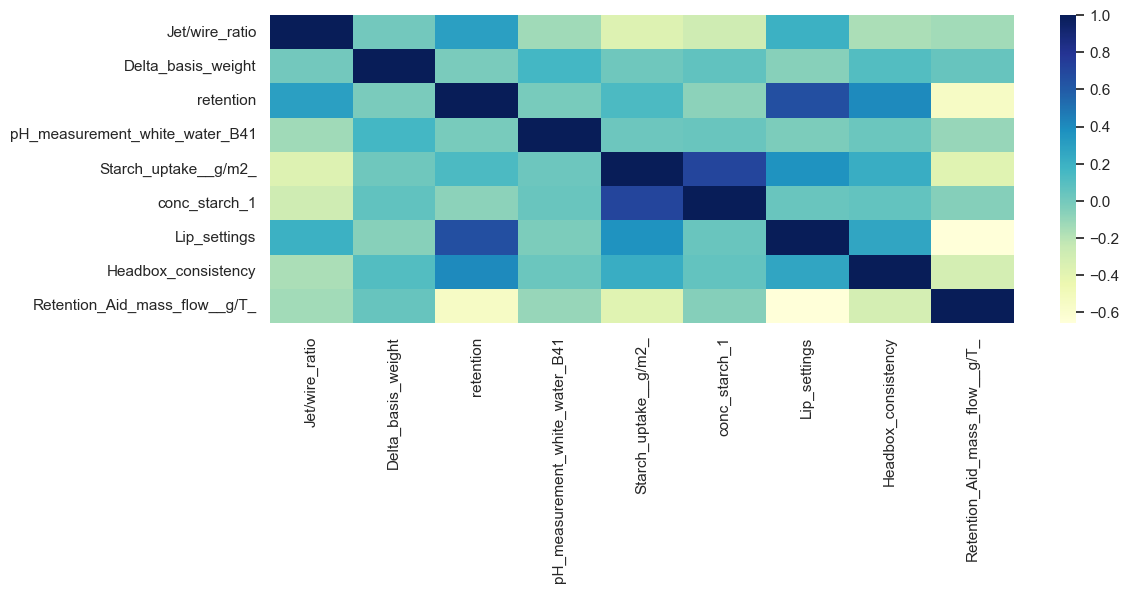

In [54]:
selected_features
sns.heatmap(X_[[v for v in selected_features if v!="grammage"]].corr(), cmap="YlGnBu")

In [55]:
s_vars=selected_features
features_to_keep_feat = s_vars
features_to_keep_filter = s_vars
for i in range(len(prep_pip.steps)):    
    _, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        s_vars_step = list(set(s_vars).intersection(set(var_trafo)))
        
        if len(s_vars_step) > 0:
            
            s_vars = list(set(s_vars) - set(s_vars_step) ) 
            features_to_keep_feat = list(set(features_to_keep_feat) - set(s_vars_step)) 
            features_to_keep_filter = list(set(features_to_keep_filter) - set(s_vars_step)) 
            features_to_keep_feat = features_to_keep_feat + var_in
            features_to_keep_filter = features_to_keep_filter + s_vars_step
    
features_to_create = [v for v in created_vars if v in  s_vars]
n_max=len(s_vars)

max_comps = 10 # min(20, len(exog_vars))
pre_estimator = Pipeline(steps=[])
pre_estimator.steps.append(("feat", FeatureCreator(features_to_create=features_to_create, features_to_keep=list(set(features_to_keep_feat)) ,errors="raise")))
for i in range(len(prep_pip.steps)):
    name_step, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        if len(list(set(features_to_keep_filter).intersection(set(var_trafo)))) > 0:        
            pre_estimator.steps.append((name_step, step))
    else:
        pre_estimator.steps.append((name_step, step))
#pre_estimator.steps.append(("filter", FeatureCreator(features_to_create=[], features_to_keep=list(set(features_to_keep_filter)),errors="raise")))
pre_estimator.steps.append(("filter", ColumnSelector(list(set(features_to_keep_filter)))))


main_estimator= make_estimator_for_selected(features_to_keep_filter)

estimator = Pipeline(pre_estimator.steps + main_estimator.steps)


In [56]:
features_to_keep_filter

['Delta_basis_weight',
 'Jet/wire_ratio',
 'retention',
 'pH_measurement_white_water_B41',
 'Starch_uptake__g/m2_',
 'Lip_settings',
 'grammage',
 'Headbox_consistency',
 'Retention_Aid_mass_flow__g/T_',
 'conc_starch_1']

In [57]:
param_grid={"ridge__alpha": np.logspace(1, 5, 100)}
#param_grid = {"pca__base_estimator__n_components": list(range(1, max_comps + 1)), "ridge__alpha":  np.logspace(-4, 3, 20)}

    
model = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    refit=True,            # refit best model on all training data
)

if "feat" in model.estimator.named_steps:
    fr = model.estimator.named_steps["feat"].features_required()
    sv = [v for v in features_to_keep_feat if v not in features_to_create]
    sel_vars=list(set(fr + sv))
    model.fit(Xtr[sel_vars],ytr)
else:    
    sel_vars=s_vars
    model.fit(Xtr[sel_vars],ytr)

In [58]:
model.best_params_

{'ridge__alpha': np.float64(53.3669923120631)}

 Test Set Performance
RMSE : 0.0491
MAE  : 0.0384
R²   : 0.9278


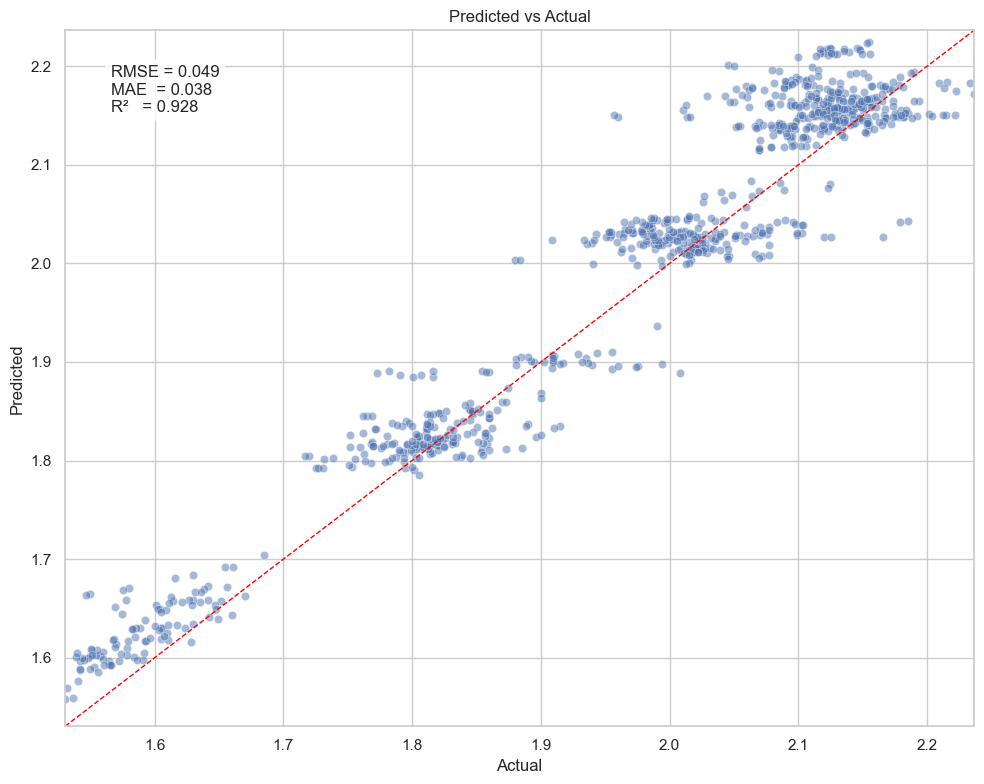

In [59]:
ypred = model.predict(Xte[sel_vars])
# metrics
rmse = root_mean_squared_error(yte, ypred)
mae = mean_absolute_error(yte, ypred)
r2 = r2_score(yte, ypred)
 
# pretty print in console
print("="*40)
print(" Test Set Performance")
print("="*40)
print(f"RMSE : {rmse:,.4f}")
print(f"MAE  : {mae:,.4f}")
print(f"R²   : {r2:,.4f}")
print("="*40)
 
# scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
 
sns.scatterplot(x=yte, y=ypred, alpha=0.5, ax=ax)
 
lims = [
    np.nanmin([yte.min(), ypred.min()]),
    np.nanmax([yte.max(), ypred.max()])
]
 
ax.plot(lims, lims, linestyle="--", color="red", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
 
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs Actual")
 
# add metrics box inside plot
textstr = "\n".join((
    f"RMSE = {rmse:.3f}",
    f"MAE  = {mae:.3f}",
    f"R²   = {r2:.3f}",
))
 
ax.text(
    0.05, 0.95,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
 
plt.tight_layout()
plt.show()

In [254]:
from utility import calculate_manual_shap, plotly_shap_beeswarm

base, shap_vals, X_explain, feats = calculate_manual_shap(model.best_estimator_, X_reference=Xtr[sel_vars+["AB_Grade_ID"]], X_sample=Xte[sel_vars+["AB_Grade_ID"]], grade_id=6010120, grade_col="AB_Grade_ID")

PermutationExplainer explainer: 201it [00:29,  4.47it/s]                         


In [255]:
fig = plotly_shap_beeswarm(shap_vals, X_explain, feats, max_features=100)
fig.show()

In [60]:
if "feat" in model.estimator.named_steps:
    fr = model.estimator.named_steps["feat"].features_required()
    sv = [v for v in features_to_keep_feat if v not in features_to_create]
    sel_vars=list(set(fr + sv))
    model.best_estimator_.fit(X[sel_vars],y)
else:    
    sel_vars=s_vars
    model.best_estimator_.fit(X[sel_vars],y)

In [61]:
with open(f"SCTCD_model_{k_target}.pkl", 'wb') as f:
        pickle.dump(model, f)

# SCT MD

In [37]:
turnup_data = pd.read_parquet(f"data/costimier_turnup.parquet")

In [81]:
v =  'MBS_SCT_MD'
outlier_flag = detect_outliers(turnup_ts,v,
                                    method="iqr",
                                    #group_col="AB_Grade_ID" 
                                    )
turnup_ts["outlier"] = outlier_flag

fig = px.scatter(turnup_ts.reset_index(), x="Wedge_Time", y=v,  color=turnup_ts["outlier"].map({True:"Outlier", False:"Normal"}))
fig.show()

In [71]:
from utility import update_turnup_grammage, ewm_reset

turnup_data = pd.read_parquet(f"data/costimier_turnup.parquet")
ycol = "MBS_SCT_MD"
grade = ""

lags = 0
time_aware = True
candidate_lags = None
use_holdout = True

created_vars=[
            "Starch_uptake__g/m2_",
            "Water_flow_Predryer",
            "Water_flow_Afterdryer",
            "Water_flow",
            "flow_diluted_starch",
            "Fibre__g/m2_",
            "Water_flow_Afterdryer_input", 
            "Water_flow_Afterdryer_output",
            "dewatering",
        ]

turnup_data = transform(turnup_data,ycol)

if len(created_vars)>0:
    fc = FeatureCreator(features_to_create=created_vars, features_to_keep= list(set(turnup_data.columns.to_list()+created_vars)))
    turnup_data = fc.fit_transform(turnup_data)
    fr = fc.features_required()
else:
    fr=[]


turnup_data = turnup_data[turnup_data['Steam_flow_to_PreDryers']<=70]
turnup_data = turnup_data[turnup_data.index>"2025-04-01 00:00:00"]
turnup_data = turnup_data[~outlier(turnup_data[ycol], option="PctClip")]

if ycol== 'Steam_flow_to_PreDryers' or True:
    turnup_data = turnup_data[~outlier(turnup_data["Water_flow_Predryer"], option="PctClip")]
if ycol== 'Steam_flow_to_AfterDryers' or True:
    turnup_data = turnup_data[turnup_data["Water_flow_Afterdryer"]<15.5 ]
    turnup_data = turnup_data[turnup_data["flow_diluted_starch"]<30]
if ycol== 'Condensate_energy_from_paper_plant_to_power_plant' or True:
    turnup_data = turnup_data[~((turnup_data.index>"2026-01-11 12:00") & (turnup_data.index<"2026-01-12 11:00"))]
    turnup_data = turnup_data[~((turnup_data.index>"2026-01-17 12:00") & (turnup_data.index<"2026-01-19 11:00"))]
    turnup_data = turnup_data[((turnup_data["Condensate_energy_from_paper_plant_to_power_plant"]<10) & (turnup_data["Condensate_energy_from_paper_plant_to_power_plant"]>5))]

turnup_data = turnup_data[turnup_data.DG4_Temperature_Inlet_Air > 100]

turnup_data = turnup_data[turnup_data.grammage.isin([85,90,95,100,110,115,120,125,130,135])]
turnup_data = turnup_data[turnup_data.paper_type.isin(["3200", "6010", "3300"])]

turnup_data["inverse_speed"] = 1 / (turnup_data["Speed_PD1"]**2)


turnup_ts =turnup_data.copy()
turnup_ts = turnup_ts.sort_index()

turnup_ts = turnup_ts[turnup_ts.index<"2026-02-01"]

turnup_ts["Delta_basis_weight"] = turnup_ts["Current_basis_weight"] - turnup_ts["grammage"]
turnup_ts["grammage"] = turnup_ts["grammage"].astype("category")

update_turnup_grammage(turnup_ts)
turnup_ts["AB_Grade_ID"] = turnup_ts["AB_Grade_ID"].astype(int)

exog_vars = list(set(control_vars[ycol.replace("MBS_SCT_MD","MBS_SCT_CD")] + fr + ["grammage"])) + ["Delta_basis_weight"]

candidate_lags = None

extra_vars = ["AB_Grade_ID"]

lags = 0
filter = True

if filter:
    grade_change = turnup_ts["AB_Grade_ID"].ne(turnup_ts["AB_Grade_ID"].shift())
    gap12 = turnup_ts.index.to_series().diff().gt(pd.Timedelta("12h")).fillna(True)
    turnup_ts["seg"] = (grade_change | gap12).cumsum()

    for c in exog_vars + extra_vars + [ycol]:
        turnup_ts[c] = turnup_ts.groupby("seg", group_keys=False)[c].transform(ewm_reset)

for i in range(1,lags+1):
    exog_vars.append(f"y_L{i}")

X, y = make_design(turnup_ts, ycol, exog_vars + extra_vars, candidate_lags,y_lags=range(1,lags + 1))
time_aware=True
if time_aware:
    n = len(X)
    split = int(n*0.8)
    inner_cv = TimeSeriesSplit(n_splits=5)
    Xtr, Xte = X.iloc[:split], X.iloc[split:]
    ytr, yte = y.iloc[:split], y.iloc[split:]
else:
    inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y,test_size=0.20,shuffle=True,random_state=42)

if use_holdout:        
    outer_cv = [(np.arange(0, split), np.arange(split, n))]
else:        
    outer_cv = TimeSeriesSplit(n_splits=5) if time_aware else 5

tscv = TimeSeriesSplit(n_splits=5)


speed_vars = ['AD6_speed','AD7_speed_bottom','Speed','Forming_Wire_Speed','Speed_Size_Press','Speed_PD4_bottom', 'Speed_PD5_bottom','AD7_speed_top','Speed_PD1','Speed_PD3','Speed_PD2','Speed_PD4_top','Speed_PD5_top','Speed_press_section']
vacuum_vars = [v for v in exog_vars if "vacuum" in v.lower()] 
draw_vars = ['Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3']
speedsizer_linepressure_vars = ["SpeedSizer_Linepressure_DS","SpeedSizer_Linepressure_FS"]
linepressure_vars=["Linepressure_1st_press_FS__bar_", "Linepressure_2nd_press_FS__bar_", "Linepressure_1st_press_DS__bar_","Linepressure_2nd_press_DS__bar_", "Linepressure_shoe_press__bar_"]
conc_starch_vars = ["concentration_starch_working_tank_2", "concentration_starch_working_tank_1"]
  
#black_list = ['Thick_Stock_Consistency__%_', "grammage", "Consistency_starch_main_line"]
black_list = ['Thick_Stock_Consistency__%_', "Consistency_starch_main_line", 'Conductivity_white_water_B46', 'Bentonite_1_mass_flow__g/T_','Bentonite_2_mass_flow__g/T_',]

prep_draw = GroupwisePLSTransformer(
    pls_columns= draw_vars,
    #group_col="grammage",
    n_components=2,
    score_prefix="draw",
    remainder="passthrough",
)

prep_speedsizer_linepressure = GroupwisePLSTransformer(
    pls_columns=speedsizer_linepressure_vars,
    #group_col="grammage",
    n_components=1,
    score_prefix="speedsizer_linepressure",
    remainder="passthrough",
)

prep_linepressure = GroupwisePLSTransformer(
    pls_columns=linepressure_vars,
    #group_col="grammage",
    n_components=1,
    score_prefix="linepressure",
    remainder="passthrough",
)

prep_conc_starch = GroupwisePLSTransformer(
    pls_columns=conc_starch_vars,
    #group_col="grammage",
    n_components=1,
    score_prefix="conc_starch",
    remainder="passthrough",
)

prep_pip= Pipeline([
     ("prep_draw", prep_draw), 
     ("prep_speedsizer_linepressure",prep_speedsizer_linepressure),
     ("prep_linepressure",prep_linepressure),
     ("prep_conc_starch",prep_conc_starch)
                
])

#prep_pip= Pipeline([("prep_total", prep_total)])

Xtr_ = prep_pip.fit_transform(Xtr, ytr)
Xte_ = prep_pip.transform(Xte)

X_ = pd.concat([Xtr_,Xte_],axis=0)


fixed_features = ["grammage","Starch_uptake__g/m2_","Delta_basis_weight","Jet/wire_ratio"]#, "Current_reel_moisture_average(reel)"] #["grammage"]
exog_vars_ = fixed_features + [v for v in exog_vars if v not in black_list and v not in fr]
#exog_vars_ = list(set(exog_vars_) - set(steam_pressure + steam_diff_pressure))
for i in range(len(prep_pip.steps)):    
    _, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        #fixed_features += var_trafo
        exog_vars_ = list(set(exog_vars_ + var_trafo) - set(var_in))
#fixed_features += inlet_trafo
exog_vars_ = list(set(fixed_features + exog_vars_) )


fixed_idx = [exog_vars_.index(f) for f in fixed_features]

k_target = 12
 
# -----------------------------
# RUN (your call, adjusted)
# -----------------------------
res = cmaes_feature_selection_exact_k(
    X_[exog_vars_], np.array(y).ravel(),
    var_names = exog_vars_,
    outer_cv=outer_cv,
    base_estimator=None,
    k_target= k_target, #len(fixed_features) + 2, #k_target
    selection="topk",        # or "weightedk"
    #selection="weightedk",        # or "topk"
    max_evals=1000,
    sigma0=1.0,
    seed=42,                 # keep fixed for apples-to-apples comparisons
    verbose=True,
    report_every_gen=1,
    popsize=24,            # None -> scaled default-like popsize; or set e.g. 16/24/32
    fixed_idx=fixed_idx,
    expected_sign={},
    enable_penalty=False,
    weight_penalty=0.1,
)
 
selected_features = [exog_vars_[i] for i in res["selected_idx"]]
print("Selected n =", len(selected_features))
print("Selected features:", selected_features)
 
best_model = res["final_estimator"]
print(f"Done. n_evals={res['n_evals']}  popsize={res['popsize']}  best_loss={res['best_loss']:.5f} best_rmse={res['best_rmse']:.5f}")


CMA-ES evals (k_free=8):   0%|          | 0/1000 [00:00<?, ?it/s]

NEW BEST: loss=0.13855 rmse=0.13855k_full=12 k_free=8 evals=1
NEW BEST: loss=0.13432 rmse=0.13432k_full=12 k_free=8 evals=5
NEW BEST: loss=0.13408 rmse=0.13408k_full=12 k_free=8 evals=20
NEW BEST: loss=0.13201 rmse=0.13201k_full=12 k_free=8 evals=31
NEW BEST: loss=0.13007 rmse=0.13007k_full=12 k_free=8 evals=43
NEW BEST: loss=0.12933 rmse=0.12933k_full=12 k_free=8 evals=65
NEW BEST: loss=0.12899 rmse=0.12899k_full=12 k_free=8 evals=67
NEW BEST: loss=0.12852 rmse=0.12852k_full=12 k_free=8 evals=88
NEW BEST: loss=0.12806 rmse=0.12806k_full=12 k_free=8 evals=183
termination on {'tolflatfitness': 1}
final/bestever f-value = 1.280571e-01 1.280571e-01 after 384/183 evaluations
incumbent solution: [-3.94248808  6.93306096  5.2876456  -6.10347094 -5.304481   -4.76155643
  1.98416998 -2.50838687 ...]
std deviations: [2.82226033 2.83430851 2.80917395 2.91123056 2.8828199  3.27151359
 3.03829483 2.83439803 ...]
Selected n = 12
Selected features: ['fibre_short/long', 'Jet/wire_ratio', 'Delta_basis

<Axes: >

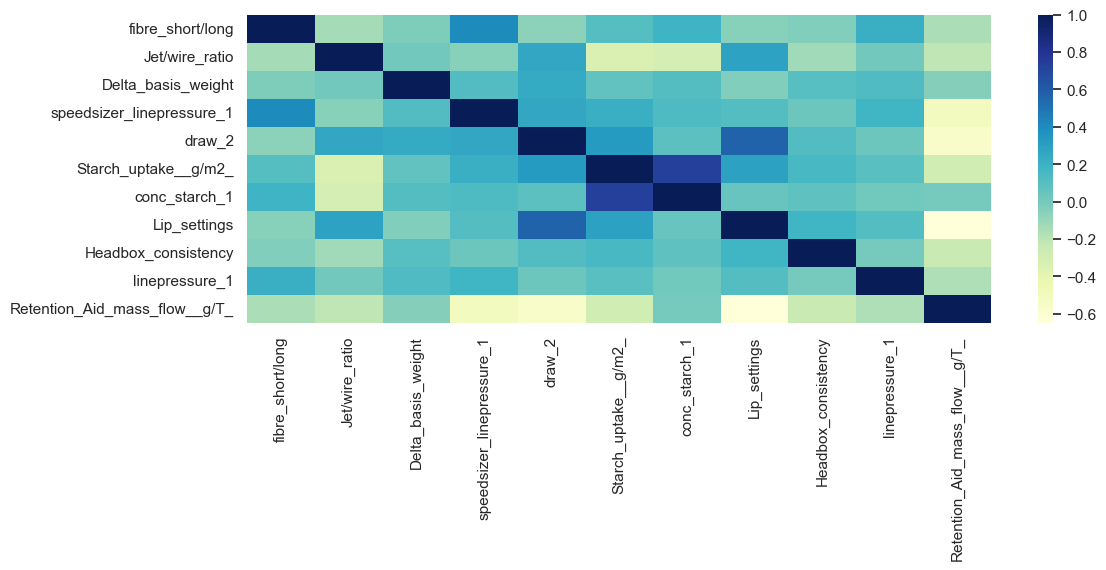

In [72]:
selected_features
sns.heatmap(X_[[v for v in selected_features if v!="grammage"]].corr(), cmap="YlGnBu")

In [73]:
s_vars=selected_features
features_to_keep_feat = s_vars
features_to_keep_filter = s_vars
for i in range(len(prep_pip.steps)):    
    _, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        s_vars_step = list(set(s_vars).intersection(set(var_trafo)))
        
        if len(s_vars_step) > 0:
            
            s_vars = list(set(s_vars) - set(s_vars_step) ) 
            features_to_keep_feat = list(set(features_to_keep_feat) - set(s_vars_step)) 
            features_to_keep_filter = list(set(features_to_keep_filter) - set(s_vars_step)) 
            features_to_keep_feat = features_to_keep_feat + var_in
            features_to_keep_filter = features_to_keep_filter + s_vars_step
    
features_to_create = [v for v in created_vars if v in  s_vars]
n_max=len(s_vars)

max_comps = 10 # min(20, len(exog_vars))
pre_estimator = Pipeline(steps=[])
pre_estimator.steps.append(("feat", FeatureCreator(features_to_create=features_to_create, features_to_keep=list(set(features_to_keep_feat)) ,errors="raise")))
for i in range(len(prep_pip.steps)):
    name_step, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        if len(list(set(features_to_keep_filter).intersection(set(var_trafo)))) > 0:        
            pre_estimator.steps.append((name_step, step))
    else:
        pre_estimator.steps.append((name_step, step))
#pre_estimator.steps.append(("filter", FeatureCreator(features_to_create=[], features_to_keep=list(set(features_to_keep_filter)),errors="raise")))
pre_estimator.steps.append(("filter", ColumnSelector(list(set(features_to_keep_filter)))))


main_estimator= make_estimator_for_selected(features_to_keep_filter)

estimator = Pipeline(pre_estimator.steps + main_estimator.steps)

In [74]:
features_to_keep_filter

['fibre_short/long',
 'Jet/wire_ratio',
 'speedsizer_linepressure_1',
 'Delta_basis_weight',
 'draw_2',
 'Starch_uptake__g/m2_',
 'Lip_settings',
 'grammage',
 'Headbox_consistency',
 'linepressure_1',
 'Retention_Aid_mass_flow__g/T_',
 'conc_starch_1']

In [75]:
param_grid={"ridge__alpha": np.logspace(1, 5, 100)}
#param_grid = {"pca__base_estimator__n_components": list(range(1, max_comps + 1)), "ridge__alpha":  np.logspace(-4, 3, 20)}

    
model = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    refit=True,            # refit best model on all training data
)

if "feat" in model.estimator.named_steps:
    fr = model.estimator.named_steps["feat"].features_required()
    sv = [v for v in features_to_keep_feat if v not in features_to_create]
    sel_vars=list(set(fr + sv))
    model.fit(Xtr[sel_vars],ytr)
else:    
    sel_vars=s_vars
    model.fit(Xtr[sel_vars],ytr)

In [76]:
model.best_params_

{'ridge__alpha': np.float64(10.0)}

 Test Set Performance
RMSE : 0.1281
MAE  : 0.0945
R²   : 0.8178


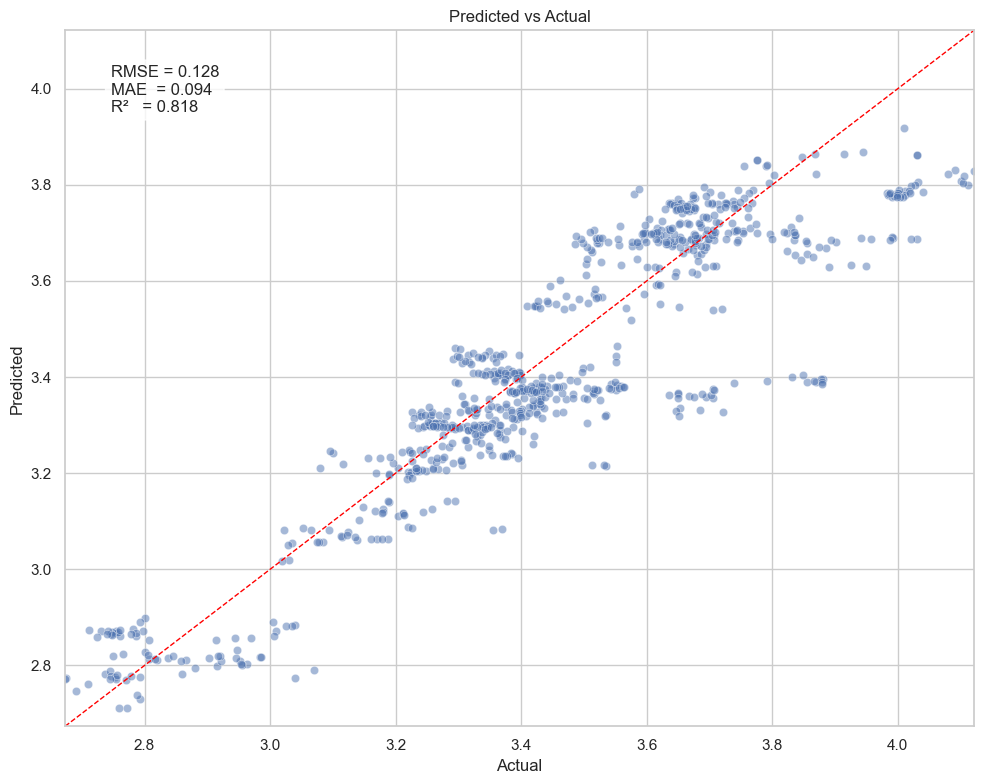

In [77]:
ypred = model.predict(Xte[sel_vars])
# metrics
rmse = root_mean_squared_error(yte, ypred)
mae = mean_absolute_error(yte, ypred)
r2 = r2_score(yte, ypred)
 
# pretty print in console
print("="*40)
print(" Test Set Performance")
print("="*40)
print(f"RMSE : {rmse:,.4f}")
print(f"MAE  : {mae:,.4f}")
print(f"R²   : {r2:,.4f}")
print("="*40)
 
# scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
 
sns.scatterplot(x=yte, y=ypred, alpha=0.5, ax=ax)
 
lims = [
    np.nanmin([yte.min(), ypred.min()]),
    np.nanmax([yte.max(), ypred.max()])
]
 
ax.plot(lims, lims, linestyle="--", color="red", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
 
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs Actual")
 
# add metrics box inside plot
textstr = "\n".join((
    f"RMSE = {rmse:.3f}",
    f"MAE  = {mae:.3f}",
    f"R²   = {r2:.3f}",
))
 
ax.text(
    0.05, 0.95,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
 
plt.tight_layout()
plt.show()

In [ ]:
from utility import calculate_manual_shap, plotly_shap_beeswarm

base, shap_vals, X_explain, feats = calculate_manual_shap(model.best_estimator_, X_reference=Xtr[sel_vars+["AB_Grade_ID"]], X_sample=Xte[sel_vars+["AB_Grade_ID"]], grade_id=6010120, grade_col="AB_Grade_ID")

In [ ]:
fig = plotly_shap_beeswarm(shap_vals, X_explain, feats, max_features=100)
fig.show()

In [69]:
if "feat" in model.estimator.named_steps:
    fr = model.estimator.named_steps["feat"].features_required()
    sv = [v for v in features_to_keep_feat if v not in features_to_create]
    sel_vars=list(set(fr + sv))
    model.best_estimator_.fit(X[sel_vars],y)
else:    
    sel_vars=s_vars
    model.best_estimator_.fit(X[sel_vars],y)

In [70]:
with open(f"SCTMD_model_{k_target}.pkl", 'wb') as f:
        pickle.dump(model, f)

# End